In [4]:
import sys
import os
import pytest

from tqdm.notebook import tqdm, trange
import jax
import jax.tree as jtu
import jax.numpy as np
import jax.random as jr
from jax import Array
from jax.flatten_util import ravel_pytree
import equinox as eqx
from zodiax.diffops import hessian
from zodiax.optimisation import eigen_projection

from optax import sgd, adam
import optimistix as optx

import amigo as amg
import dorito as drt
from dorito.model_fits import PointResolvedFit as prf
from dorito.model_fits import ResolvedOIFit
from dorito.model_fits import _OIFit
from dorito.models import ResolvedAmigoModel
from dorito.models import ResolvedDiscoModel
from dorito.bases import ImageBasis
from dorito.models import BaseModeller
from dorito.stats import disco_regularised_loss_fn


from kneed import KneeLocator

import dLux.utils as dlu

# matplotlib configs
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch
import ehtplot
import scienceplots
import cmasher as cmr
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


plt.style.use(["science", "bright", "no-latex"])
new_rcParams = {
    "svg.fonttype": "none",
    "image.cmap": "inferno",
    "font.family": "serif",
    "image.origin": "lower",
    "figure.dpi": 300,
    "font.size": 10,
    "xtick.direction": "out",
    "ytick.direction": "out",
}
plt.rcParams.update(new_rcParams)

from frito.autoencoder.ae_utils import load_classes_from_file as lcf, run_svd
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
)
from frito.jax_gaussian import gaussian_filter
from frito.autoencoder.data import(
    make_coordinate_grid,
    elliptical_polar,
    angular_asymmetry,
    make_rings, make_spiral,
    add_planet,
    sample_fourier_coeffs,
    random_rings,
    random_spiral,
    random_obj,
    bin_down
)
from sklearn.decomposition import PCA

In [ ]:
test_key = jr.key(0)

test_no_planets = [random_obj(key, planets_range=(0,5), disc_scale=(0.25,0.5)) for key in jr.split(test_key,96)]

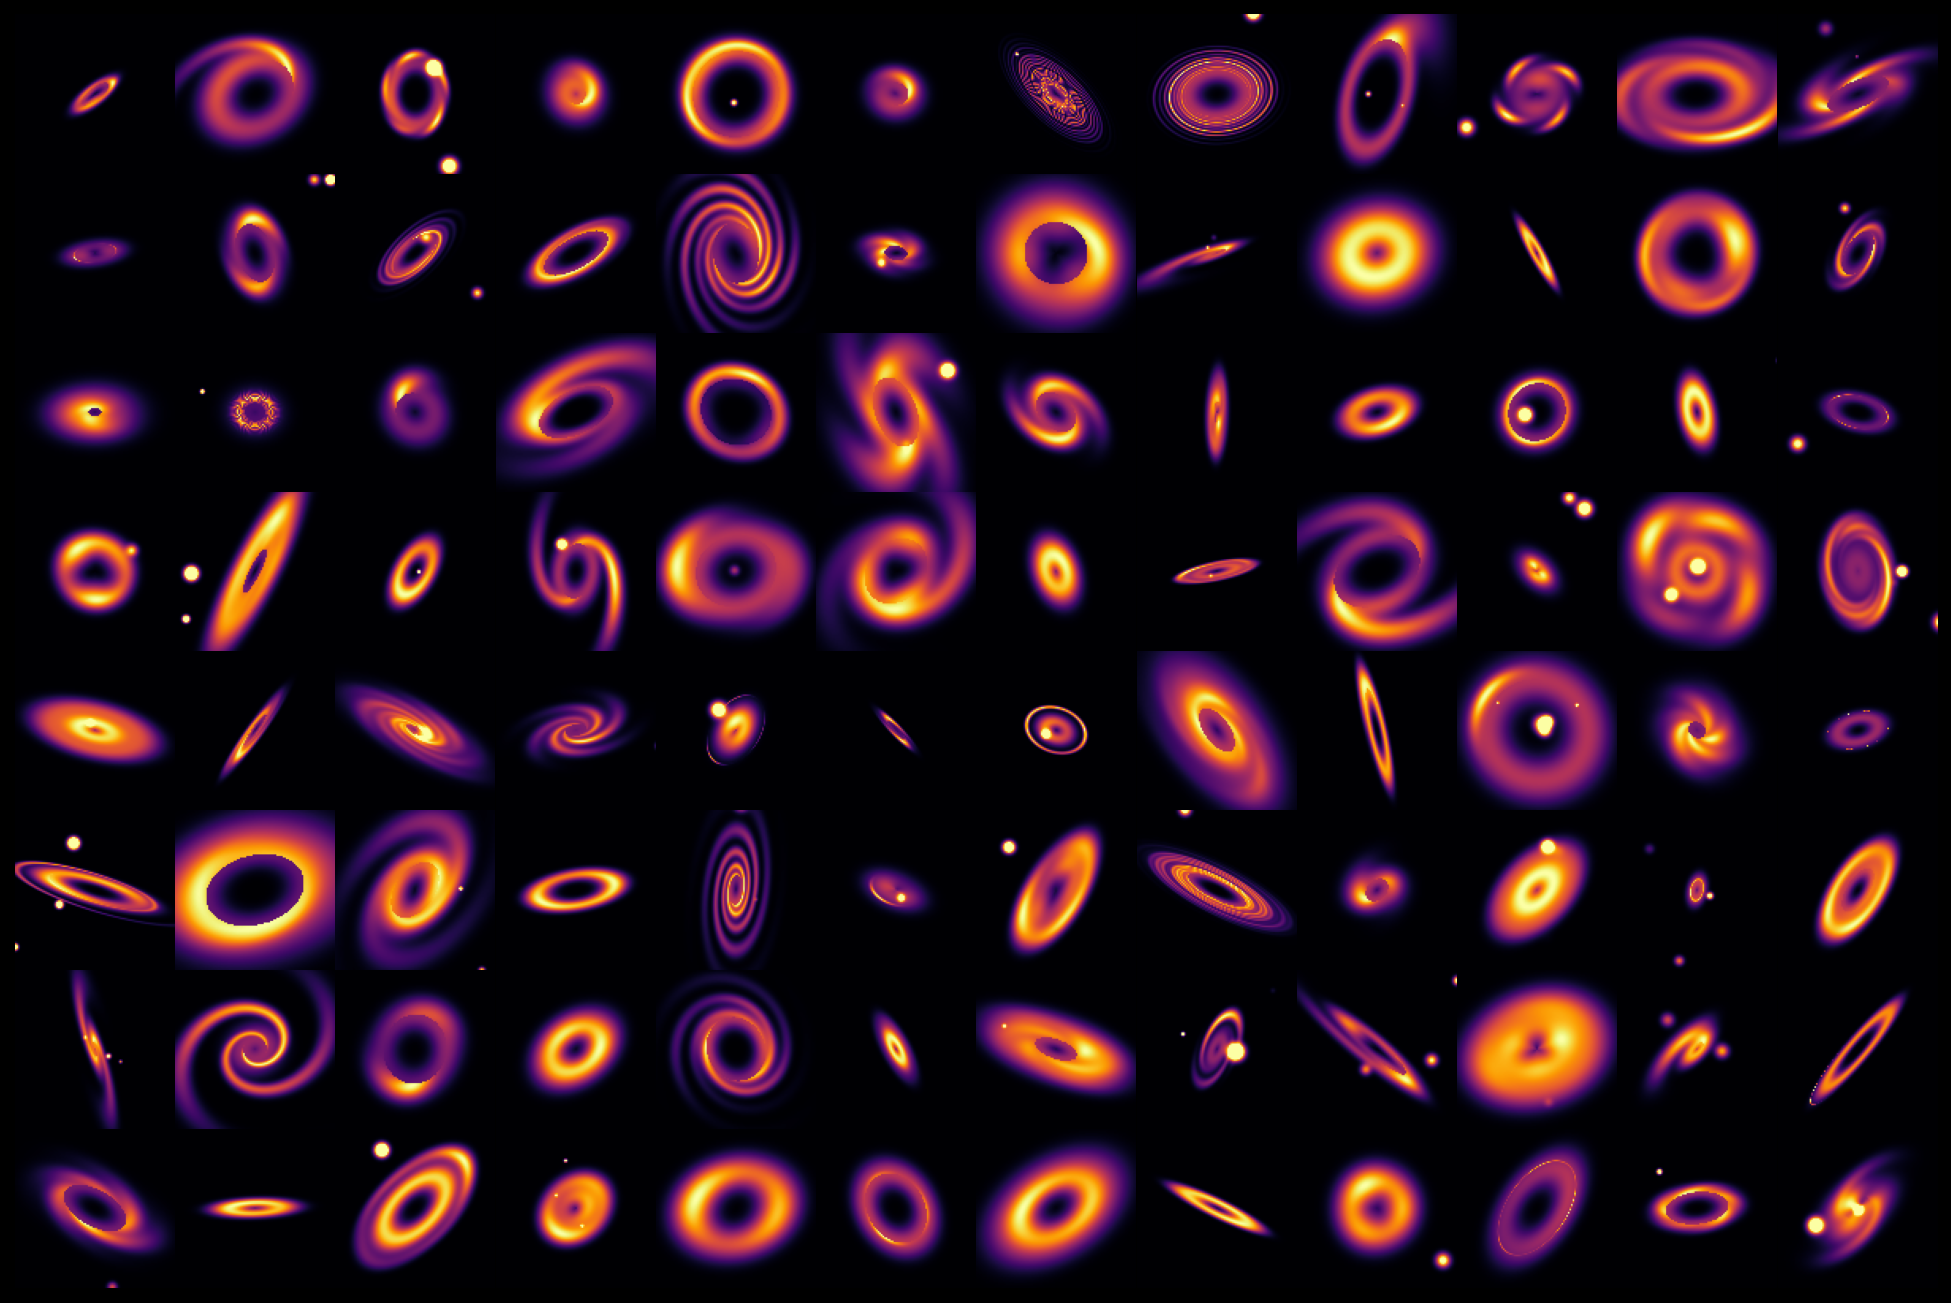

In [14]:
fig, axes = plt.subplots(8, 12, figsize=(8.27, 5.5133333333),facecolor='black')
plt.subplots_adjust(wspace=0, hspace=0)

for i, ax in enumerate(axes.flat):
    if i < 96:
        ax.imshow(test_no_planets[i], cmap='inferno')  # remove cmap if RGB images
        ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        ax.axis('off')


plt.savefig('/Users/jonahgoldfine/Documents/Important Documents/packages/frito/_plots/PPD_examples.svg', dpi=300)

In [307]:
test_planets = [random_obj(key, planets_range=(1,2), disc_scale=(0.25,0.5)) for key in jr.split(test_key,100)]

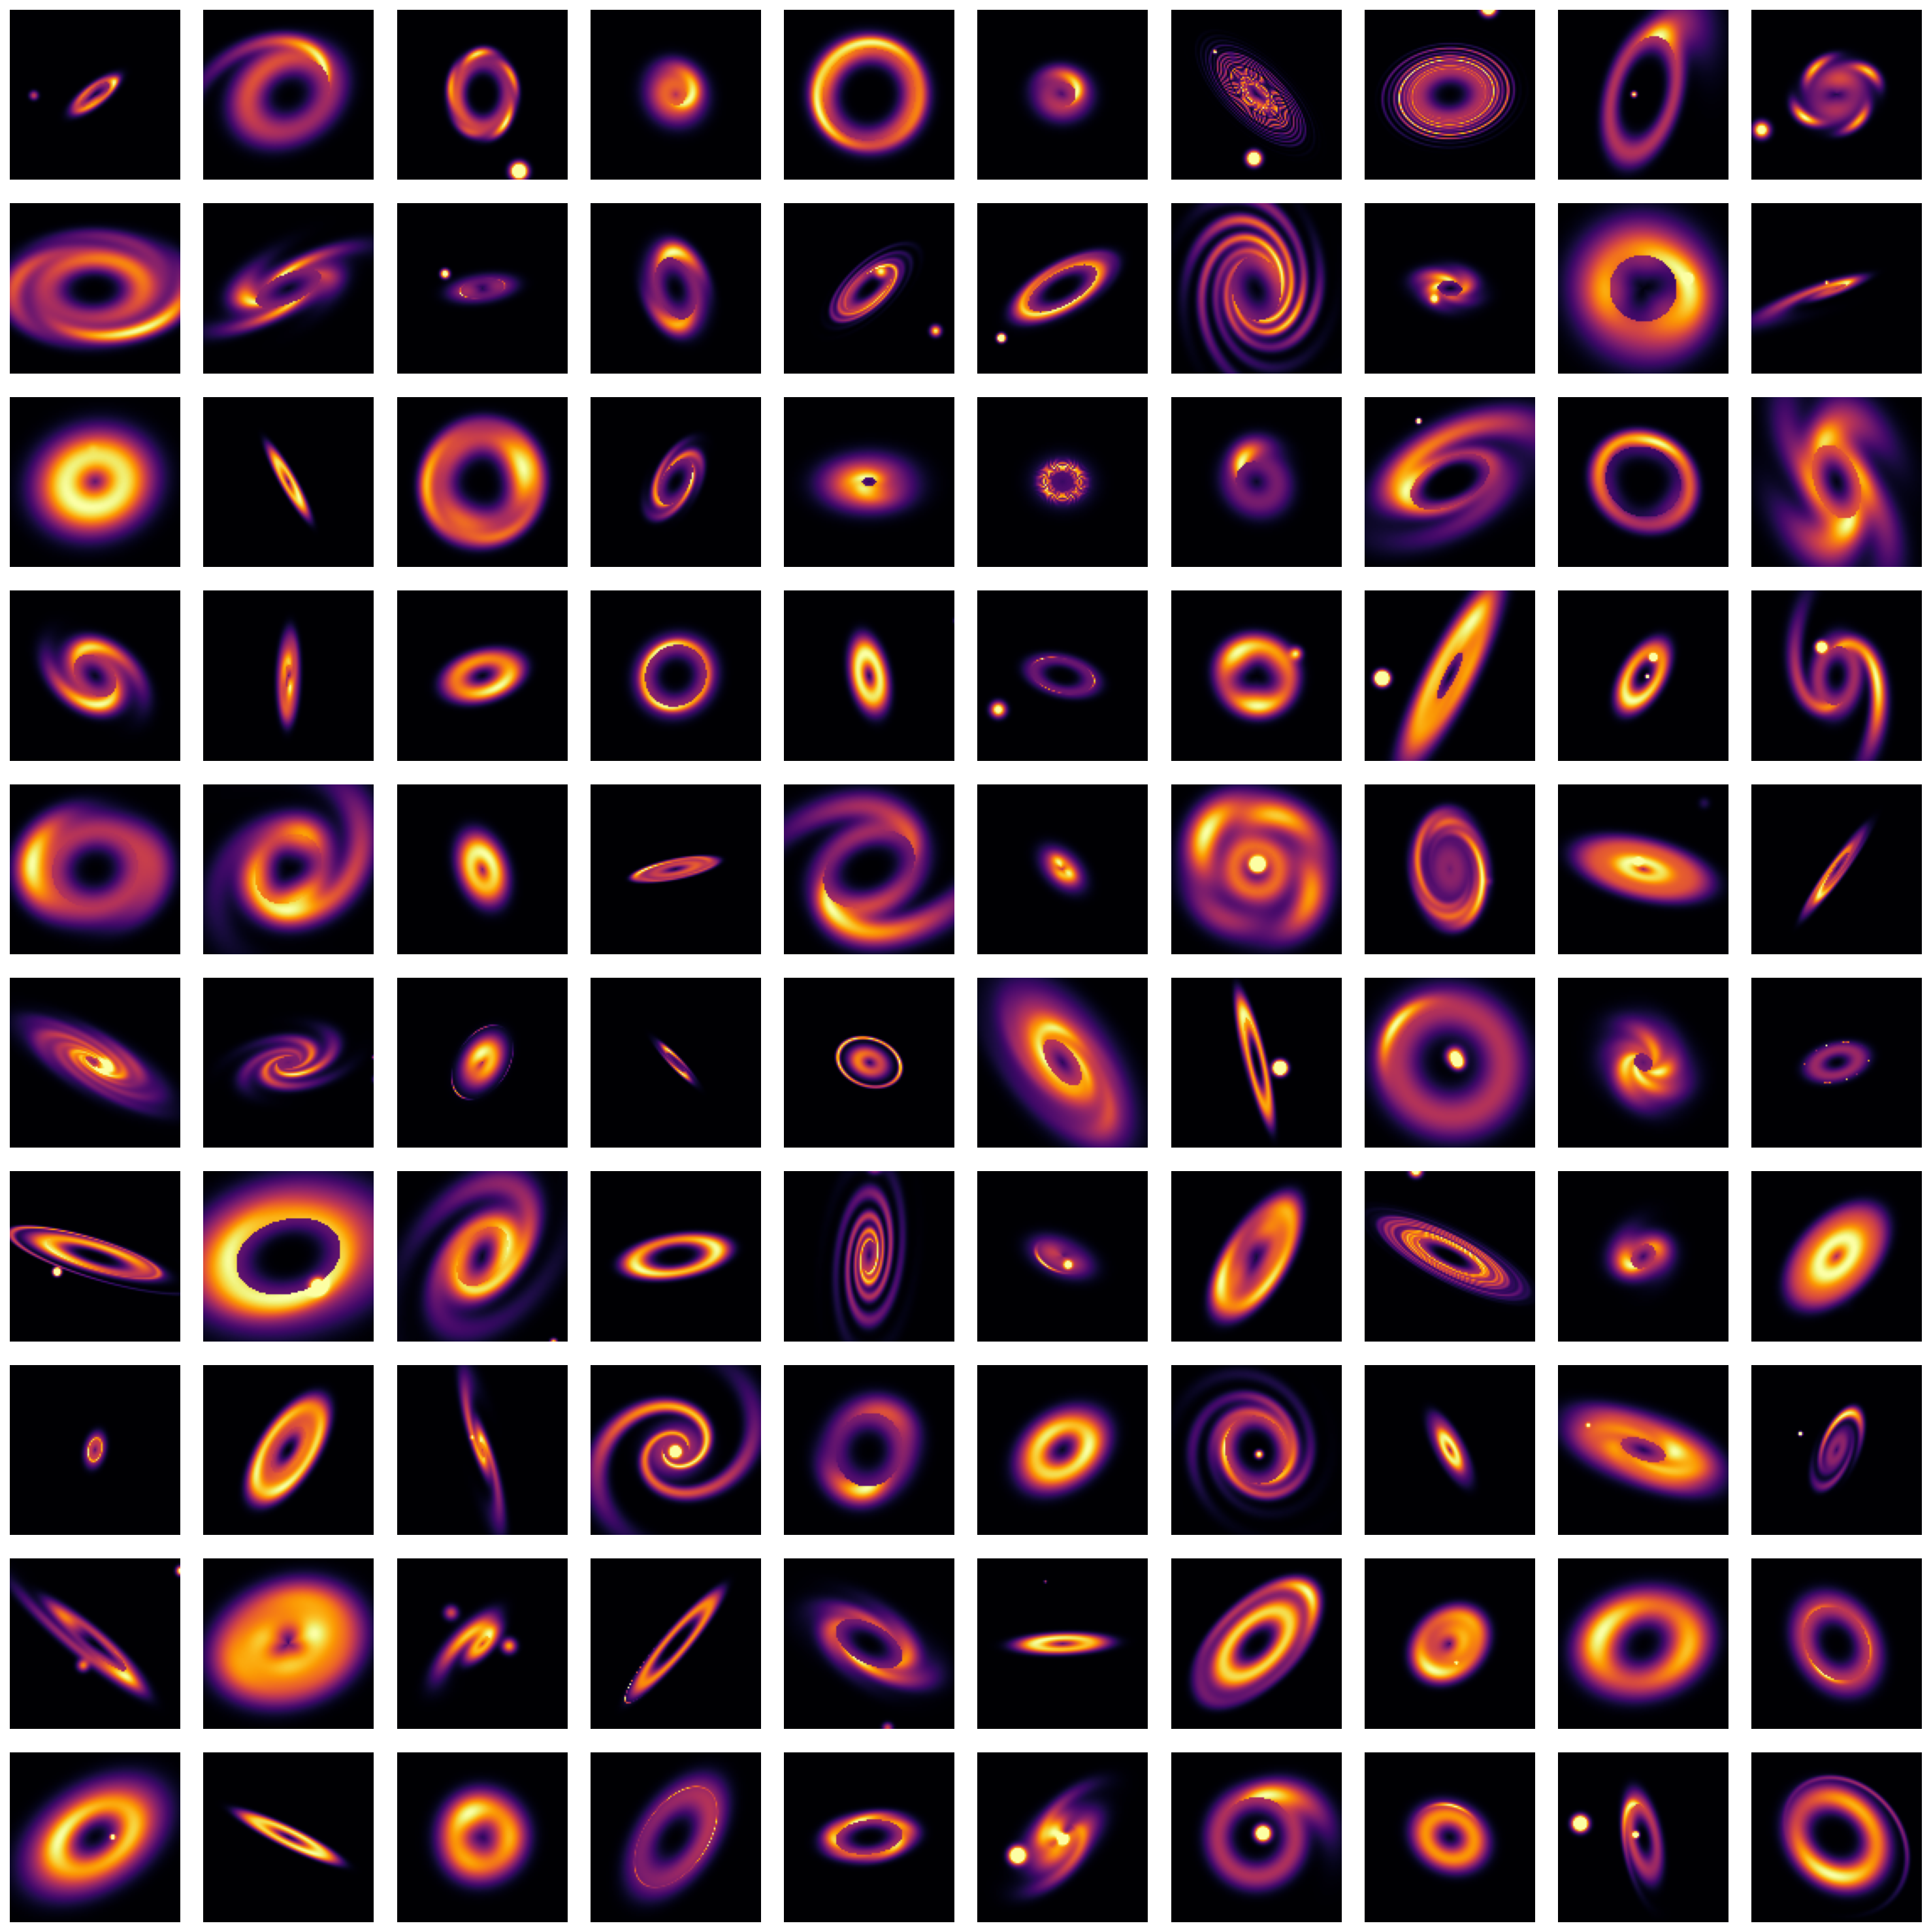

In [308]:
fig, axes = plt.subplots(10, 10, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    if i < 100:
        ax.imshow(test_planets[i], cmap='inferno')  # remove cmap if RGB images
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
master_key = jr.key(0)
master_key, data_key = jr.split(master_key, 2)
no_planets_101 = np.array([random_obj(key, planets_range=(0,0), disc_scale=(0.25,0.5)) for key in jr.split(data_key, 5000)])
no_planets = jax.vmap(bin_down)(no_planets_101)
no_planets = no_planets.reshape(5000,1,51,51)
planets_101 = np.array([random_obj(key, planets_range=(1,2), disc_scale=(0.25,0.5)) for key in jr.split(data_key, 5000)])
planets = jax.vmap(bin_down)(planets_101)
planets = planets.reshape(5000,1,51,51)

In [279]:
main_data_path = "_data"
autoencoder_data_path = os.path.join(main_data_path, "autoencoder")
main_trained_model_path = os.path.join(autoencoder_data_path, "trained_models")
main_svd_path = os.path.join(autoencoder_data_path, "svd")
training_data_path = os.path.join(autoencoder_data_path, "training_data")
emnist_path = os.path.join(training_data_path, "emnist.npz")
mnist_path = os.path.join(training_data_path, "mnist.npz")
ppd_51_path = os.path.join(training_data_path, "fake_intensity_PPDs_51x51.npz")

main_out_path = "_output"
main_model_struct_path = "src/frito/autoencoder/model_structures"

ppd_51x51_data = np.load(ppd_51_path)
test_51x51_data = ppd_51x51_data["x_test"]

disco_HD100546_path = os.path.join(
    main_data_path, "jwst", "HD100546", "disco", "cal_vis_HD-100546.npy"
)
disco_HD135344B_path = os.path.join(
    main_data_path, "jwst", "HD135344B", "disco", "cal_vis_HD135344B.npy"
)
disco_PDS70_path = os.path.join(
    main_data_path, "jwst", "PDS70", "disco", "bgmask_cal_vis_pds70.npy"
)

In [280]:
model_key, master_key = jr.split(master_key, 2)
model_type = "PPD"
i = 16
model_names = [
    "0_0",
    "0_2",
    "1_0",
    "1_2",
    "2_0",
    "2_1",
    "2_2",
    "3_0",
    "3_1",
    "3_2",
    "4_0",
    "4_1",
    "4_2",
    "7_0",
    "7_1",
    "7_2",
    "7_4",
    "7_5",
    "8_0",
    "8_2",
    "8_3",
    "8_4",
    "8_5",
    "8_6",
]
model_name = model_names[i]
model_struct_path = os.path.join(
    main_model_struct_path, f"model_{model_name}.py"
)
trained_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_best.eqx"
)
autoencoder_classes = lcf(model_struct_path)
autoencoder = autoencoder_classes["autoencoder"](key=model_key)
base_autoencoder = eqx.tree_deserialise_leaves(trained_model_path, autoencoder)

base_encoder, base_decoder = base_autoencoder.modules

print(f"Model: {model_name}")
print(f"Model Struct: {model_struct_path}")
print(f"Trained Model Path: {trained_model_path}")
print(f"Autoencoder Classes: {autoencoder_classes}")

Model: 7_4
Model Struct: src/frito/autoencoder/model_structures/model_7_4.py
Trained Model Path: _data/autoencoder/trained_models/PPD/7_4_best.eqx
Autoencoder Classes: {'autoencoder': <class 'model_7_4.autoencoder'>, 'decoder': <class 'model_7_4.decoder'>, 'encoder': <class 'model_7_4.encoder'>}


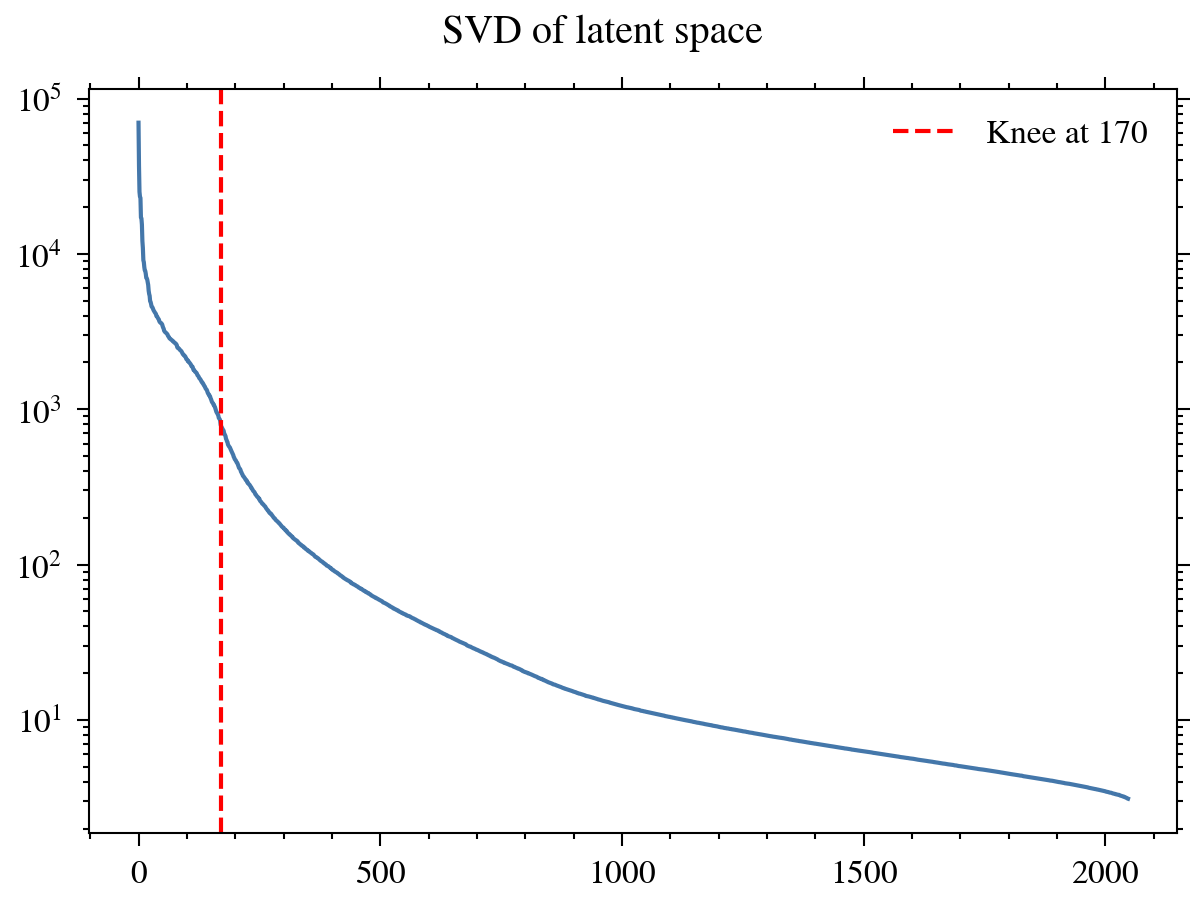

SVD Path: _data/autoencoder/svd/PPD_model_7_4_svd.npz
Knee at 170


In [281]:
svd_path = os.path.join(
    main_svd_path, f"{model_type}_model_{model_name}_svd.npz"
)
svd = np.load(svd_path)

k1 = KneeLocator(
    np.arange(len(svd["s"])),
    svd["s"],
    curve="convex",
    direction="decreasing",
    online=True,
)

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
fig.suptitle("SVD of latent space")
ax.plot(svd["s"], marker=",")
ax.axvline(k1.knee, color="r", linestyle="--", label=f"Knee at {k1.knee}")
ax.legend()
ax.set_yscale("log")
plt.show()

print(f"SVD Path: {svd_path}")
print(f"Knee at {k1.knee}")

In [282]:
def embed0(X, m, s, v):
    return (X - m) @ v.T / np.sqrt(s ** 2 / 2048)


embed_layer = eqx.nn.Lambda(
    lambda z: embed0(z, svd["mean"], svd["s"], svd["v"])
)
norm0_ae = eqx.tree_at(
    lambda m: m.modules[0].layers,
    base_autoencoder,
    base_autoencoder.modules[0].layers + [embed_layer],
)

def unembed0(embedded, m, s, v):
    return ((embedded) * np.sqrt(s ** 2 / 2048)) @ v + m


unembed_layer = eqx.nn.Lambda(
    lambda z: unembed0(z, svd["mean"], svd["s"], svd["v"])
)
norm0_ae = eqx.tree_at(
    lambda m: m.modules[1].layers,
    norm0_ae,
    [unembed_layer] + norm0_ae.modules[1].layers,
)
def sum2unity(X):
    pix_sum = np.sum(X, axis=(1,2), keepdims=True)
    norm_pix = X/pix_sum
    return norm_pix

sum2unity_layer     = eqx.nn.Lambda(lambda z: sum2unity(z))
norm0_ae     = eqx.tree_at(
        lambda m: m.modules[1].layers,
        norm0_ae,
        norm0_ae.modules[1].layers + [sum2unity_layer]
)
norm0_encoder, norm0_decoder = norm0_ae.modules

In [283]:
tmp_keys = jr.split(master_key, 3)
suture_keys = tmp_keys[:2]
master_key = tmp_keys[2]

new_encode_in = base_autoencoder.modules[0].layers[-1].in_features
new_encode_out = int(k1.knee)
new_encode_latent_weights = (
    base_autoencoder.modules[0].layers[-1].weight[:new_encode_out, :]
)
new_encode_latent_biases = (
    base_autoencoder.modules[0].layers[-1].bias[:new_encode_out]
)
new_encode_linear = eqx.nn.Linear(
    in_features=new_encode_in, out_features=new_encode_out, key=suture_keys[0]
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.weight, new_encode_linear, new_encode_latent_weights
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_encode_linear, new_encode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers[-1],
    base_autoencoder,
    trained_new_encode_linear,
)


def embed(X, knee, m, s, v):
    return (X - m[:knee]) @ v[:knee, :knee].T / np.sqrt(s[:knee] ** 2 / knee)


embed_layer = eqx.nn.Lambda(
    lambda z: embed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers,
    sutured_ae_struct,
    sutured_ae_struct.modules[0].layers + [embed_layer],
)


def unembed(embedded, knee, m, s, v):
    return ((embedded) * np.sqrt(s[:knee] ** 2 / knee)) @ v[:knee, :knee] + m[
        :knee
    ]


unembed_layer = eqx.nn.Lambda(
    lambda z: unembed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers,
    sutured_ae_struct,
    [unembed_layer] + sutured_ae_struct.modules[1].layers,
)

new_decode_out = sutured_ae_struct.modules[1].layers[2].out_features
new_decode_in = int(k1.knee)
new_decode_latent_weights = (
    sutured_ae_struct.modules[1].layers[2].weight[:, :new_decode_in]
)
new_decode_latent_biases = sutured_ae_struct.modules[1].layers[2].bias
new_decode_linear = eqx.nn.Linear(
    in_features=new_decode_in, out_features=new_decode_out, key=suture_keys[1]
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.weight, new_decode_linear, new_decode_latent_weights
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_decode_linear, new_decode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers[2],
    sutured_ae_struct,
    trained_new_decode_linear,
)

sutured_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_Rbest.eqx"
)
sutured_ae = eqx.tree_deserialise_leaves(sutured_model_path, sutured_ae_struct)
print(f"Suture Model Path: {sutured_model_path}")

def sum2unity(X):
    pix_sum = np.sum(X, axis=(1,2), keepdims=True)
    norm_pix = X/pix_sum
    return norm_pix

sum2unity_layer     = eqx.nn.Lambda(lambda z: sum2unity(z))
norm_sutured_ae     = eqx.tree_at(
        lambda m: m.modules[1].layers,
        sutured_ae,
        sutured_ae.modules[1].layers + [sum2unity_layer]
)

# encoder, decoder = sutured_ae.modules
norm1_encoder, norm1_decoder = norm_sutured_ae.modules

Suture Model Path: _data/autoencoder/trained_models/PPD/7_4_Rbest.eqx


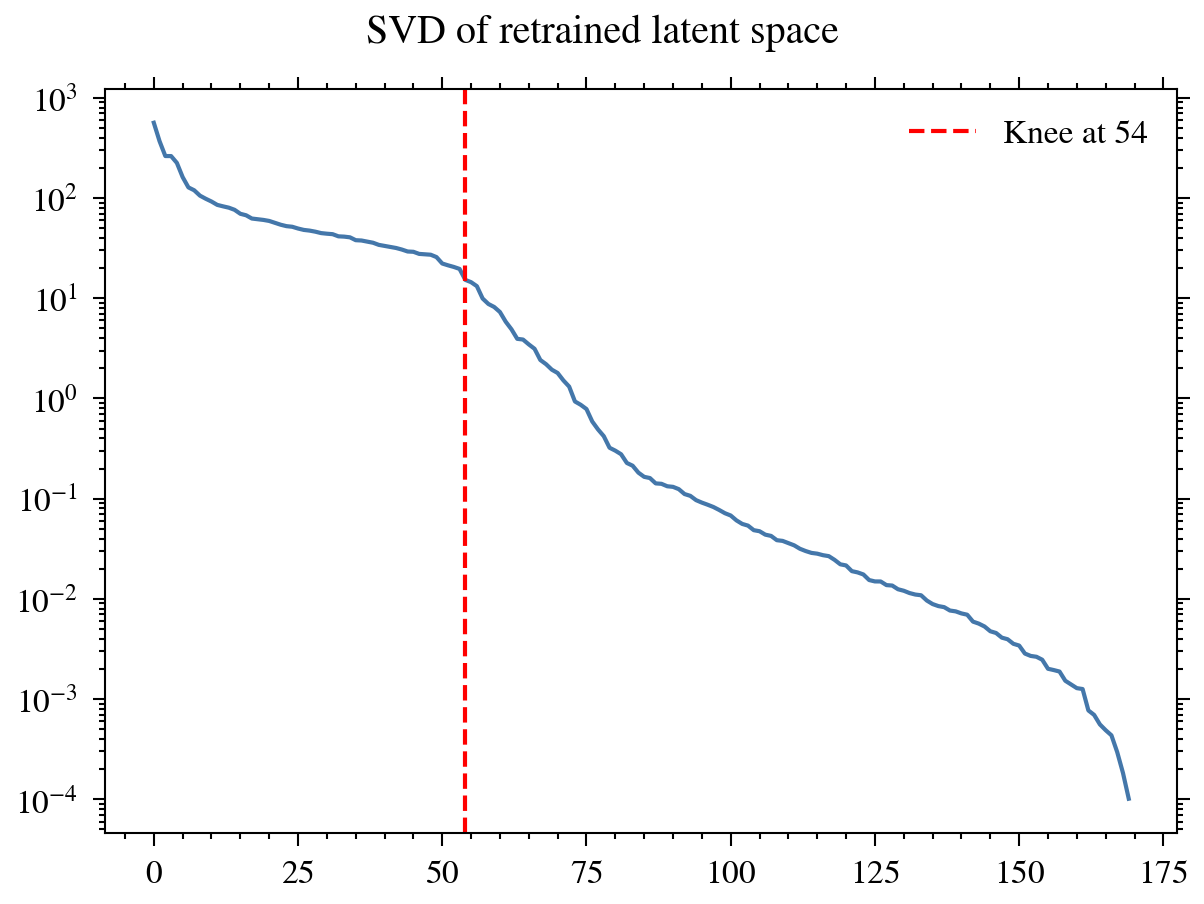

SVD Path: _data/autoencoder/svd/PPD_retrain_model_7_4_svd.npz
Knee at 54


In [284]:
svd2_path = os.path.join(
    main_svd_path, f"{model_type}_retrain_model_{model_name}_svd.npz"
)
svd2 = np.load(svd2_path)
k2 = KneeLocator(
    np.arange(len(svd2["s"])),
    svd2["s"],
    curve="convex",
    direction="decreasing",
    online=True,
)

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
fig.suptitle("SVD of retrained latent space")
ax.plot(svd2["s"], marker=",")
ax.axvline(k2.knee, color="r", linestyle="--", label=f"Knee at {k2.knee}")
ax.legend()
ax.set_yscale("log")
plt.show()

print(f"SVD Path: {svd2_path}")
print(f"Knee at {k2.knee}")

In [285]:
def embed2(X, m, s, v):
    return (X - m) @ v.T / np.sqrt(s ** 2 / 170)


embed_layer2 = eqx.nn.Lambda(
    lambda z: embed2(z, svd2['mean'], svd2['s'], svd2['v'])
)
norm2_sutured_ae = eqx.tree_at(
    lambda m: m.modules[0].layers,
    norm_sutured_ae,
    norm_sutured_ae.modules[0].layers + [embed_layer2],
)


def unembed2(embedded, m, s, v):
    return ((embedded) * np.sqrt(s ** 2 / 170)) @ v + m


unembed_layer2 = eqx.nn.Lambda(
    lambda z: unembed2(z, svd2['mean'], svd2['s'], svd2['v'])
)
norm2_sutured_ae = eqx.tree_at(
    lambda m: m.modules[1].layers,
    norm2_sutured_ae,
    [unembed_layer2] + norm2_sutured_ae.modules[1].layers,#[1:],
)
norm2_encoder, norm2_decoder = norm2_sutured_ae.modules

In [286]:
no_planets_base_latent = jax.vmap(base_encoder)(no_planets)
planets_base_latent = jax.vmap(base_encoder)(planets)
no_planets_norm0_latent = jax.vmap(norm0_encoder)(no_planets)
planets_norm0_latent = jax.vmap(norm0_encoder)(planets)
no_planets_norm1_latent = jax.vmap(norm1_encoder)(no_planets)
planets_norm1_latent = jax.vmap(norm1_encoder)(planets)
no_planets_norm2_latent = jax.vmap(norm2_encoder)(no_planets)
planets_norm2_latent = jax.vmap(norm2_encoder)(planets)

Text(0.5, 0.98, 'Non Norm 2048')

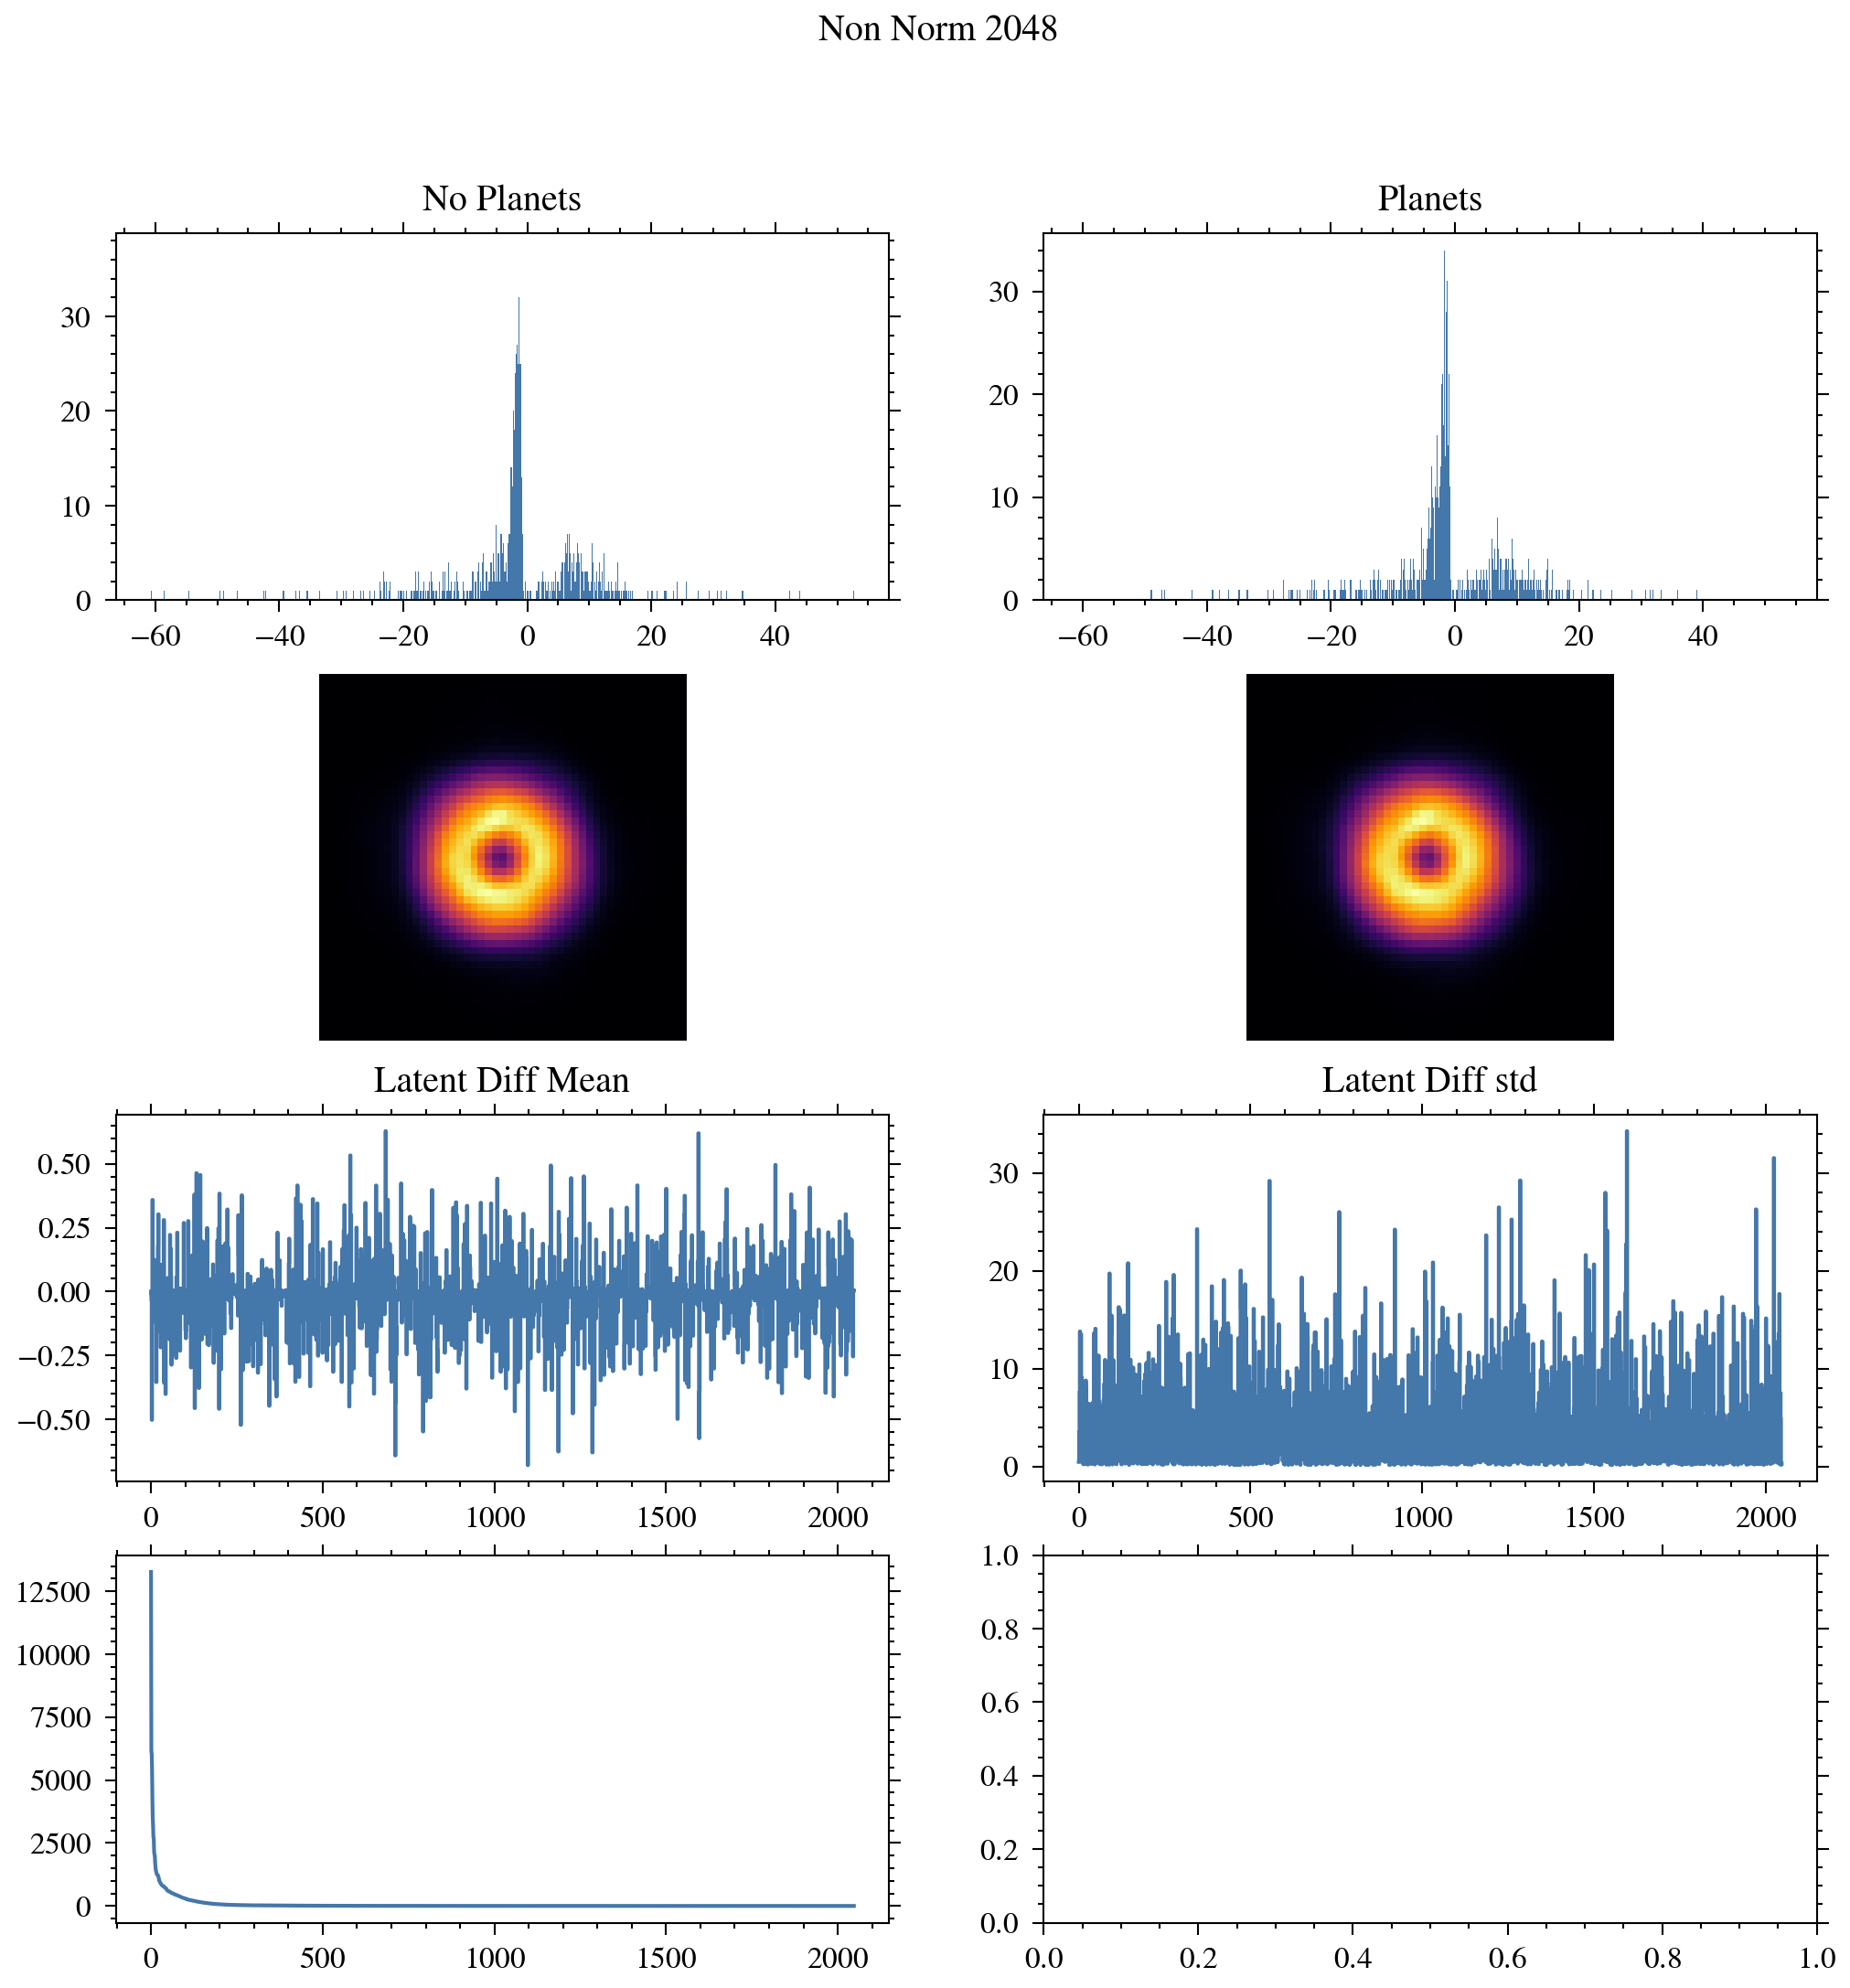

In [287]:
no_planets_base_latent_mean = np.mean(no_planets_base_latent, axis=0)
planets_base_latent_mean = np.mean(planets_base_latent, axis=0)
fig, axes = plt.subplots(4,2, figsize=(8,8))
axes[0,0].hist(no_planets_base_latent_mean, bins=2048)
axes[0,0].set_title('No Planets')
axes[0,1].hist( planets_base_latent_mean, bins=2048)
axes[0,1].set_title('Planets')
axes[1,0].imshow(base_decoder(no_planets_base_latent_mean)[0])
axes[1,0].set_axis_off()
axes[1,1].imshow(base_decoder(planets_base_latent_mean)[0])
axes[1,1].set_axis_off()
base_latent_diff = no_planets_base_latent-planets_base_latent_mean
base_latent_diff_mean = np.mean(base_latent_diff, axis=0)
axes[2,0].step(np.arange(2048), base_latent_diff_mean)
axes[2,0].set_title('Latent Diff Mean')
base_latent_diff_std = np.std(base_latent_diff, axis=0)
axes[2,1].step(np.arange(2048), base_latent_diff_std)
axes[2,1].set_title('Latent Diff std')
latent_diff_mean0 = base_latent_diff - base_latent_diff_mean
u,s,v = np.linalg.svd(latent_diff_mean0)
axes[3,0].plot(np.arange(2048), s)
fig.suptitle('Non Norm 2048')

Text(0.5, 0.98, 'Norm0 2048')

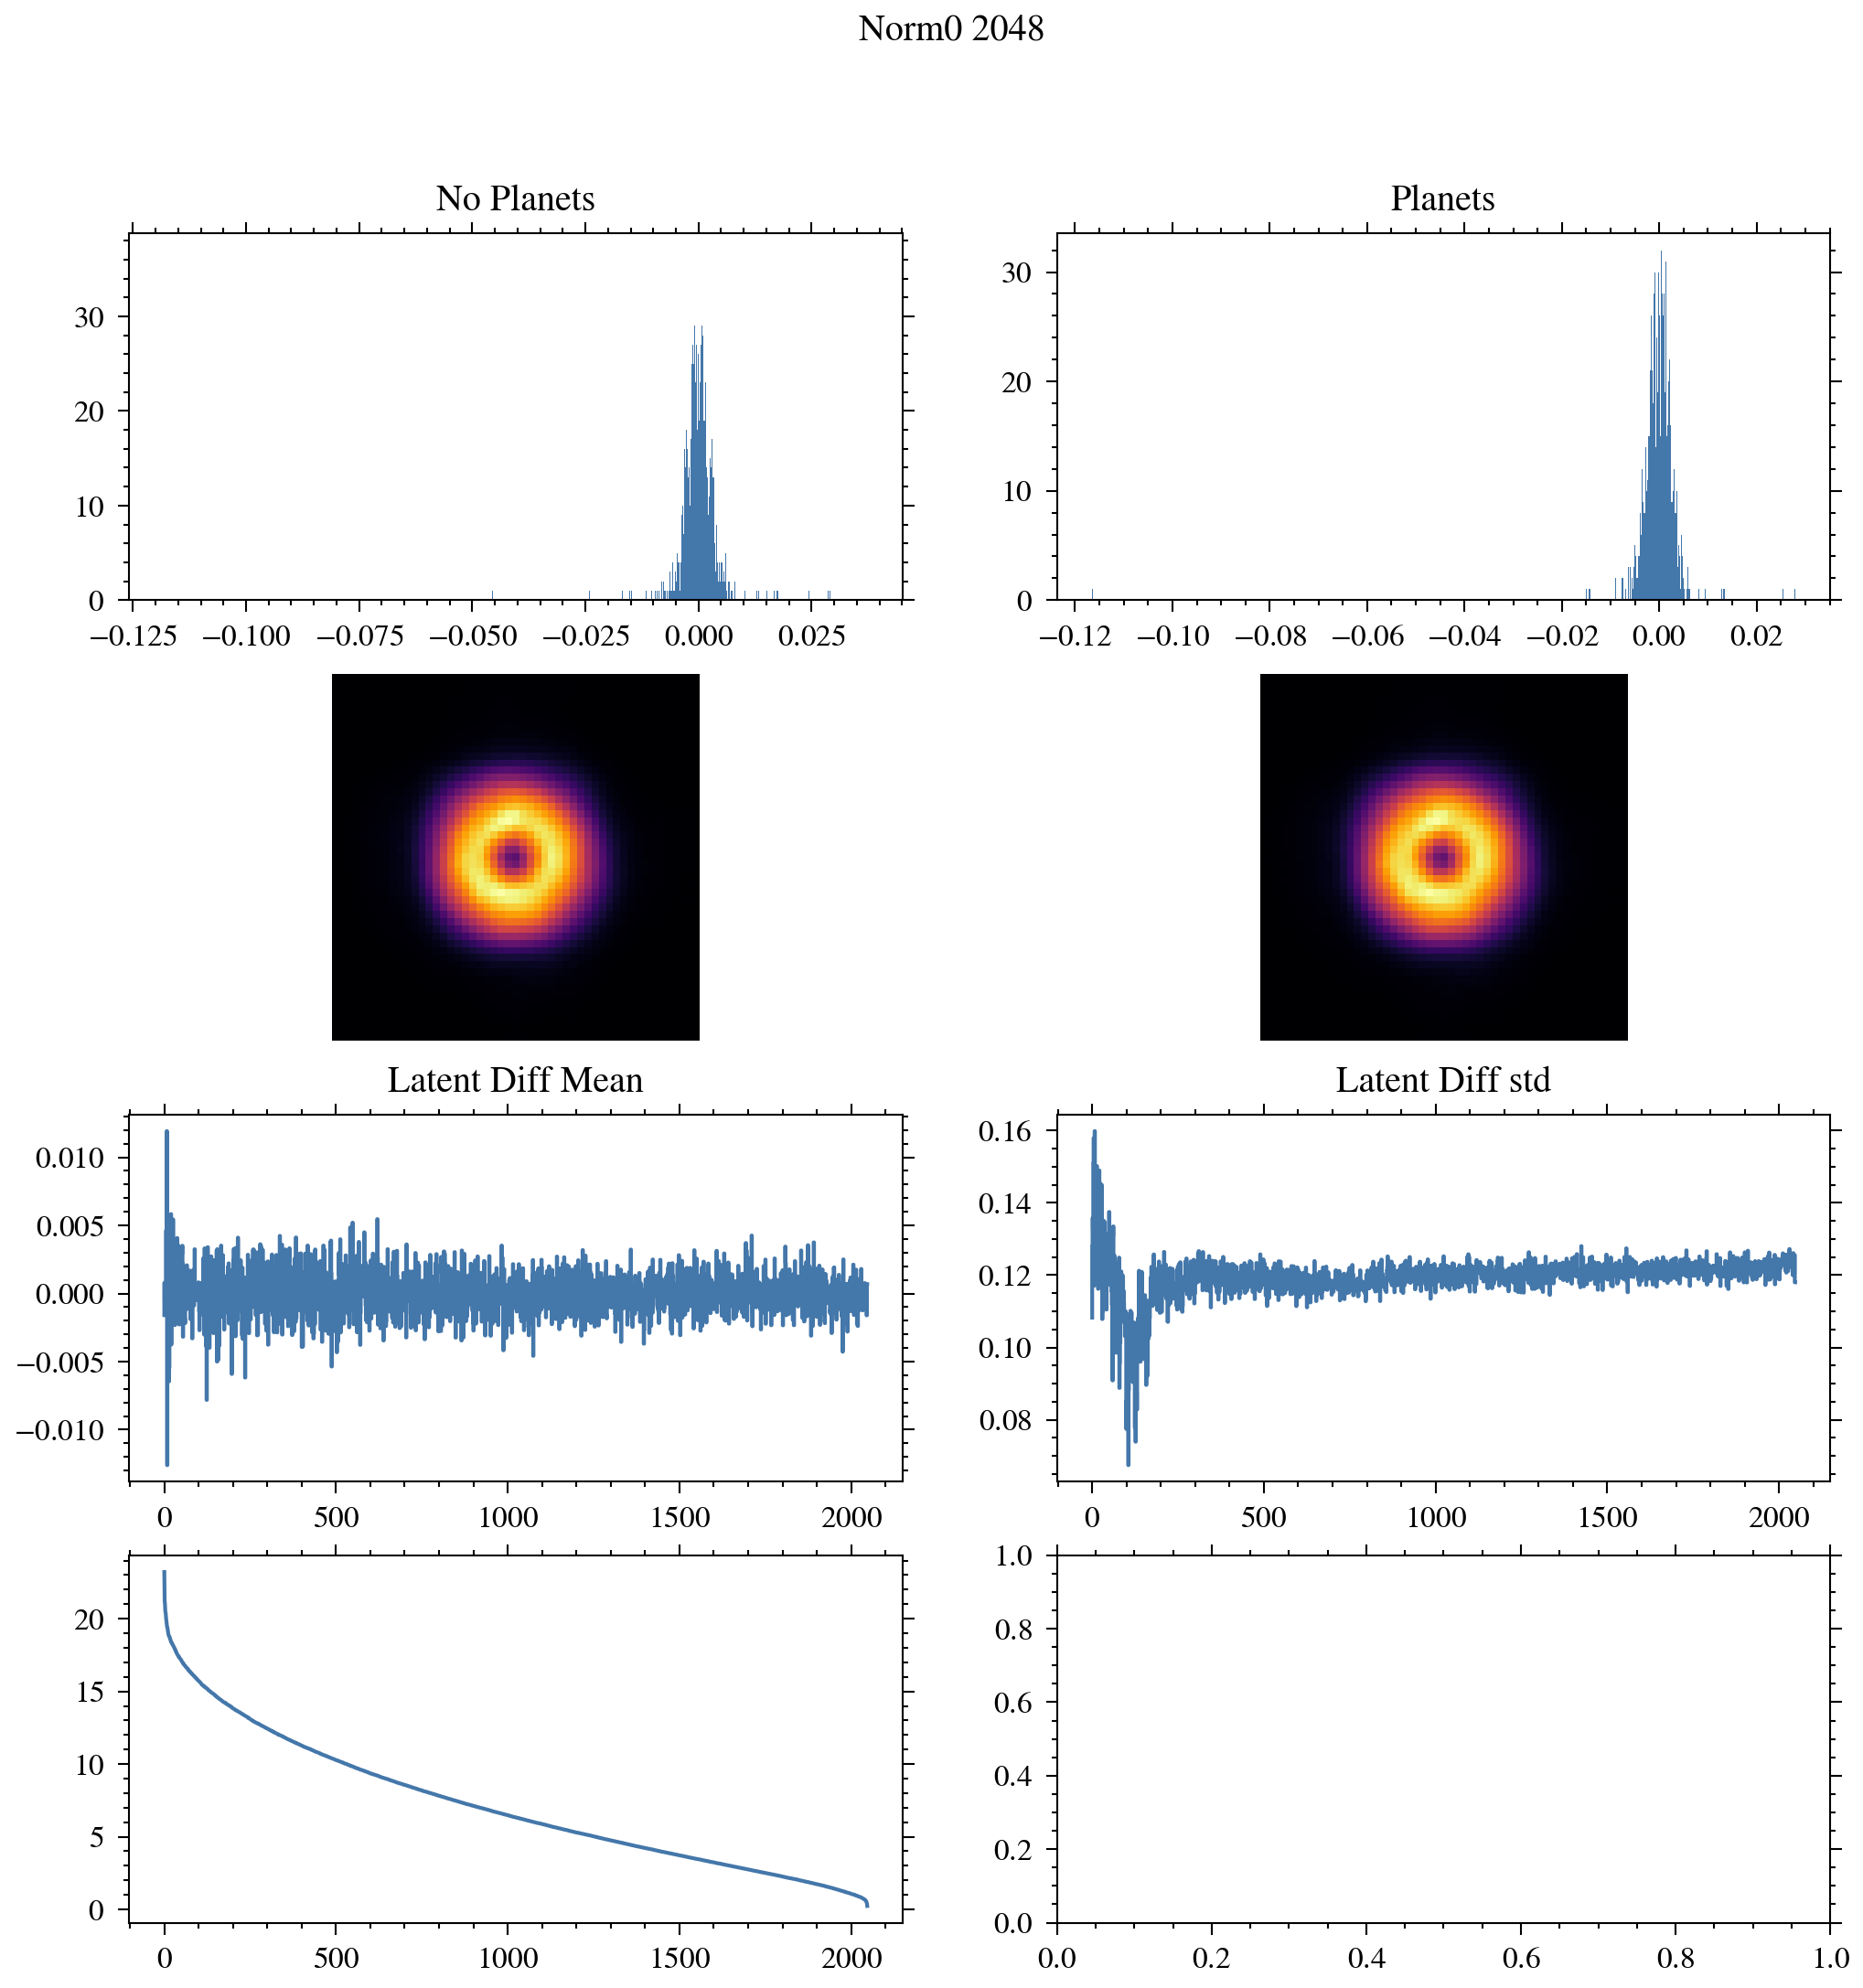

In [288]:
no_planets_norm0_latent_mean = np.mean(no_planets_norm0_latent, axis=0)
planets_norm0_latent_mean = np.mean(planets_norm0_latent, axis=0)
fig, axes = plt.subplots(4,2, figsize=(8,8))
axes[0,0].hist(no_planets_norm0_latent_mean, bins=2048)
axes[0,0].set_title('No Planets')
axes[0,1].hist( planets_norm0_latent_mean, bins=2048)
axes[0,1].set_title('Planets')
axes[1,0].imshow(norm0_decoder(no_planets_norm0_latent_mean)[0])
axes[1,0].set_axis_off()
axes[1,1].imshow(norm0_decoder(planets_norm0_latent_mean)[0])
axes[1,1].set_axis_off()
norm0_latent_diff = no_planets_norm0_latent-planets_norm0_latent_mean
norm0_latent_diff_mean = np.mean(norm0_latent_diff, axis=0)
axes[2,0].step(np.arange(2048), norm0_latent_diff_mean)
axes[2,0].set_title('Latent Diff Mean')
norm0_latent_diff_std = np.std(norm0_latent_diff, axis=0)
axes[2,1].step(np.arange(2048), norm0_latent_diff_std)
axes[2,1].set_title('Latent Diff std')
latent_diff_mean0 = norm0_latent_diff - norm0_latent_diff_mean
u,s,v = np.linalg.svd(latent_diff_mean0)
axes[3,0].plot(np.arange(2048), s)
fig.suptitle('Norm0 2048')

Text(0.5, 0.98, 'Norm1 170')

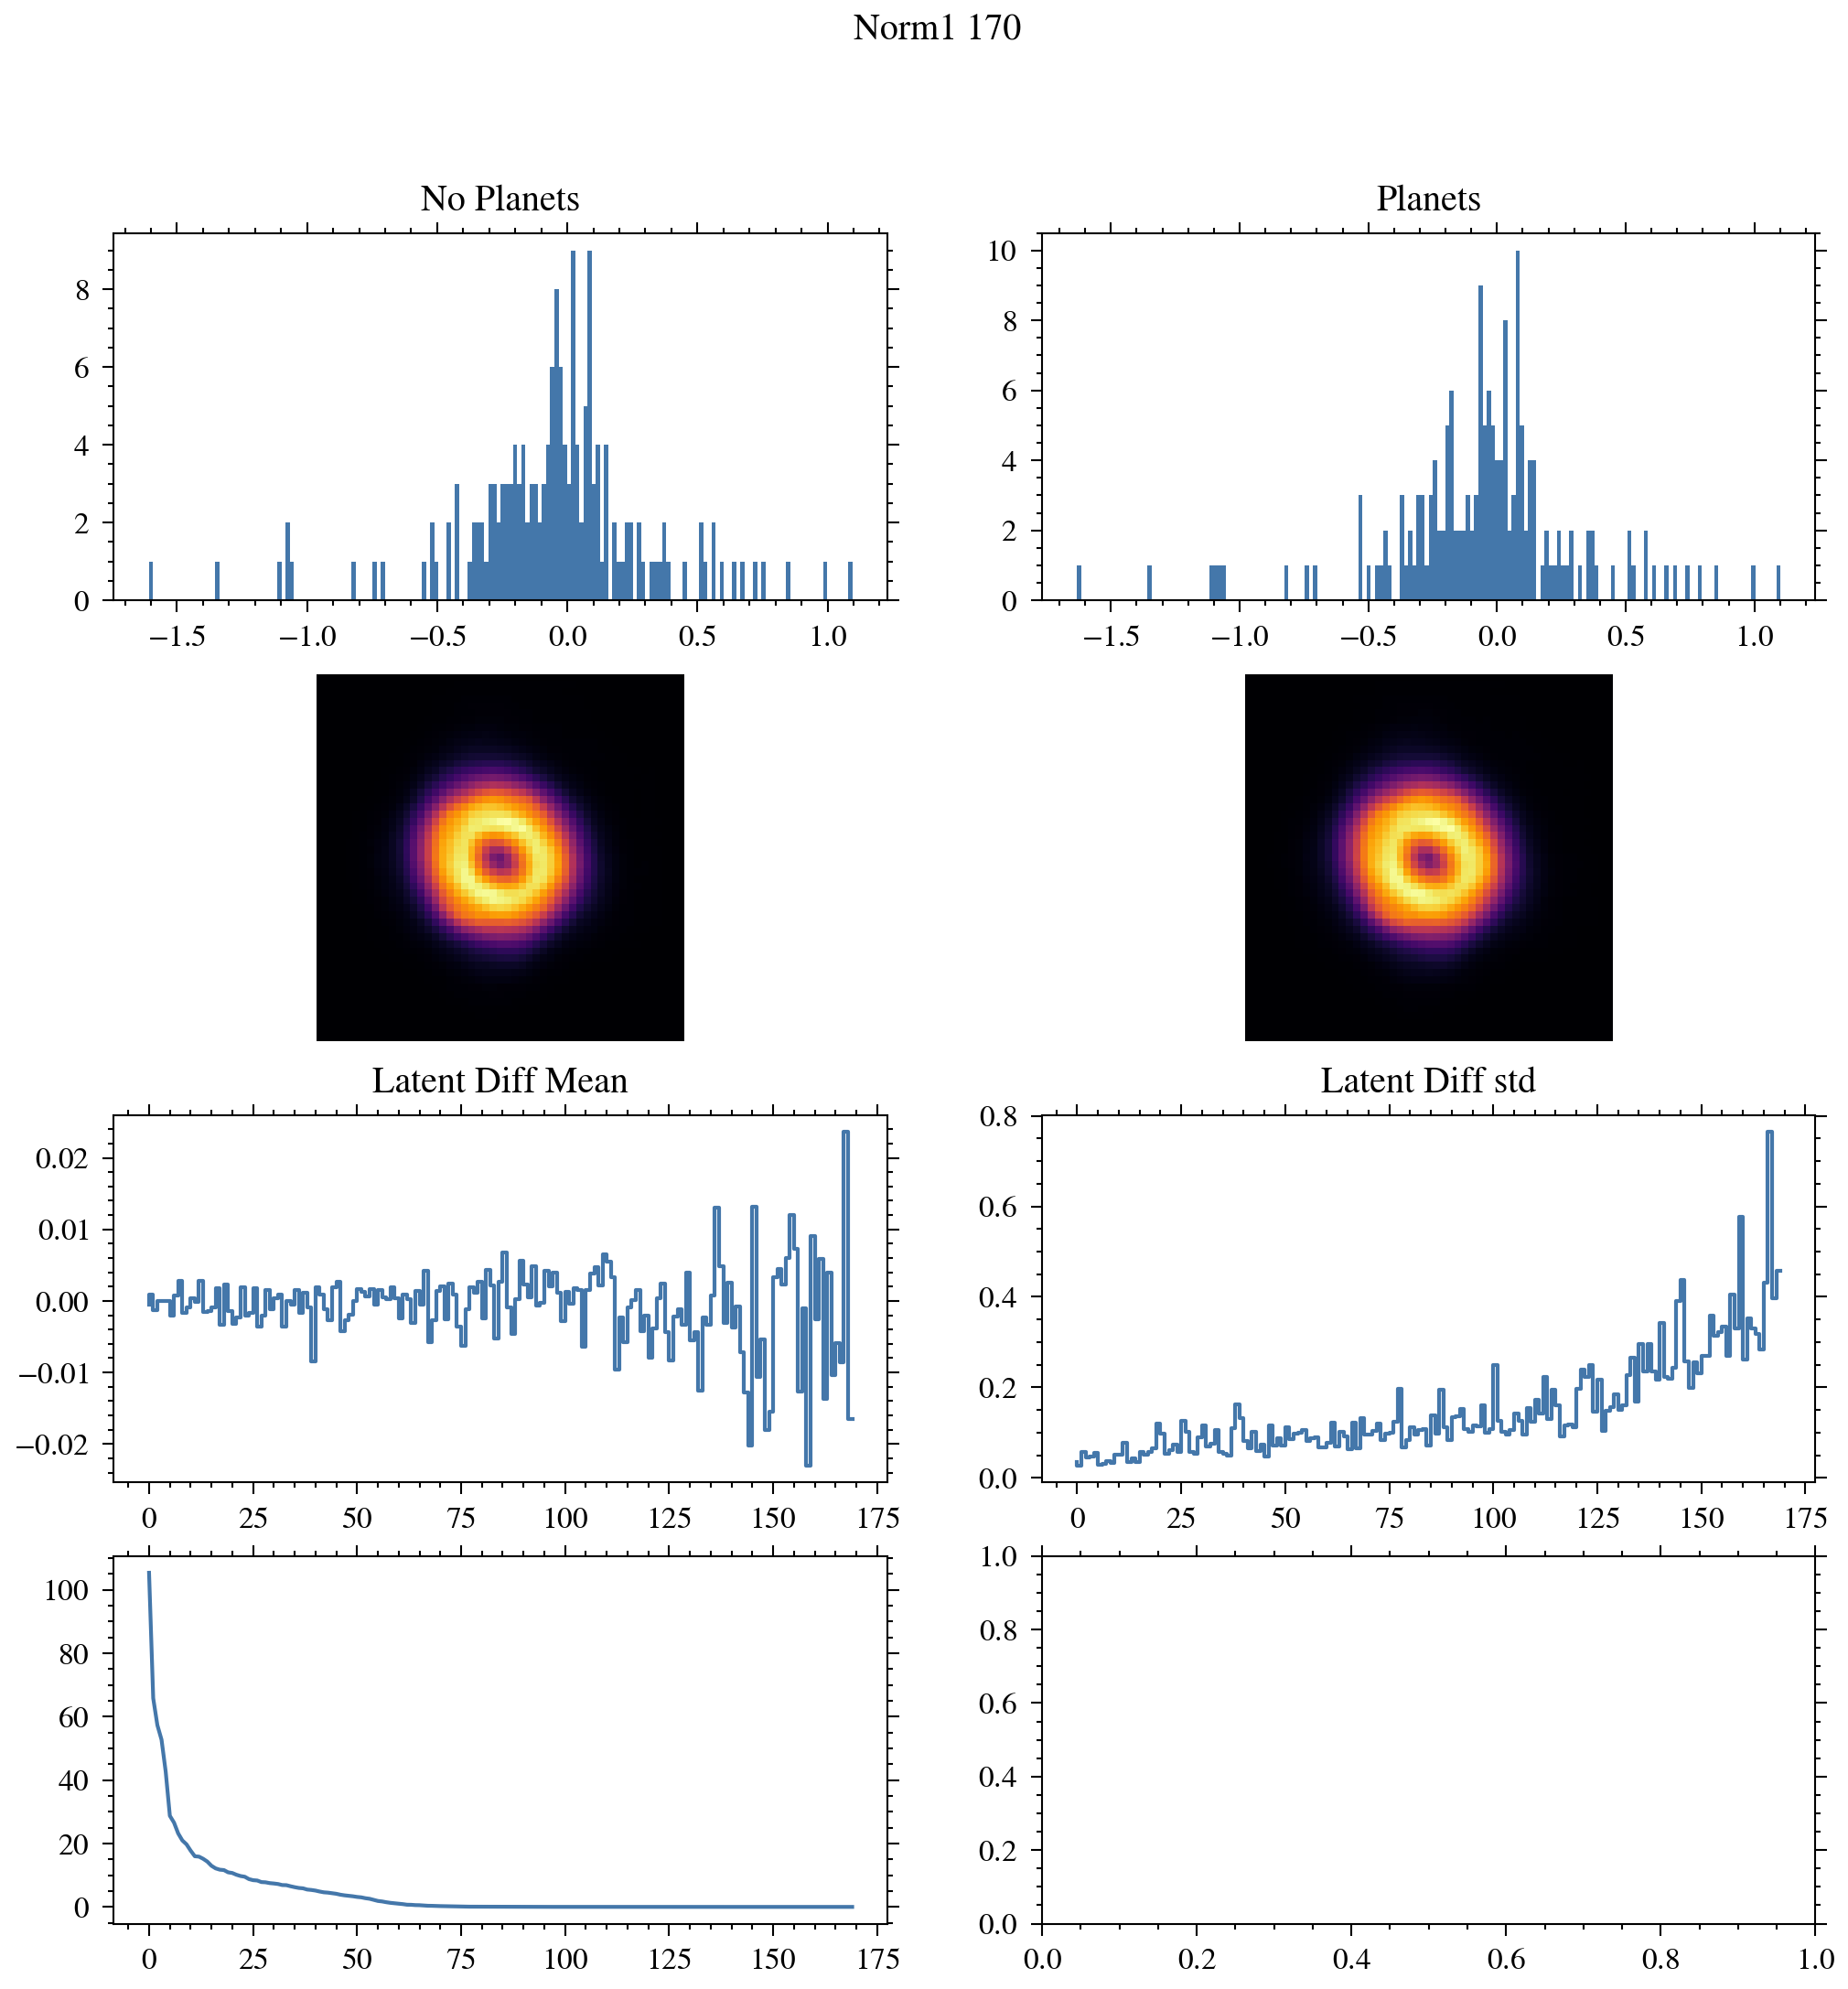

In [289]:
no_planets_norm1_latent_mean = np.mean(no_planets_norm1_latent, axis=0)
planets_norm1_latent_mean = np.mean(planets_norm1_latent, axis=0)
fig, axes = plt.subplots(4,2, figsize=(8,8))
axes[0,0].hist(no_planets_norm1_latent_mean, bins=170)
axes[0,0].set_title('No Planets')
axes[0,1].hist( planets_norm1_latent_mean, bins=170)
axes[0,1].set_title('Planets')
axes[1,0].imshow(norm1_decoder(no_planets_norm1_latent_mean)[0])
axes[1,0].set_axis_off()
axes[1,1].imshow(norm1_decoder(planets_norm1_latent_mean)[0])
axes[1,1].set_axis_off()
norm1_latent_diff = no_planets_norm1_latent-planets_norm1_latent_mean
norm1_latent_diff_mean = np.mean(norm1_latent_diff, axis=0)
axes[2,0].step(np.arange(170), norm1_latent_diff_mean)
axes[2,0].set_title('Latent Diff Mean')
norm1_latent_diff_std = np.std(norm1_latent_diff, axis=0)
axes[2,1].step(np.arange(170), norm1_latent_diff_std)
axes[2,1].set_title('Latent Diff std')
latent_diff_mean0 = norm1_latent_diff - norm1_latent_diff_mean
u,s,v = np.linalg.svd(latent_diff_mean0)
axes[3,0].plot(np.arange(170), s)
fig.suptitle('Norm1 170')

Text(0.5, 0.98, 'Norm2 170')

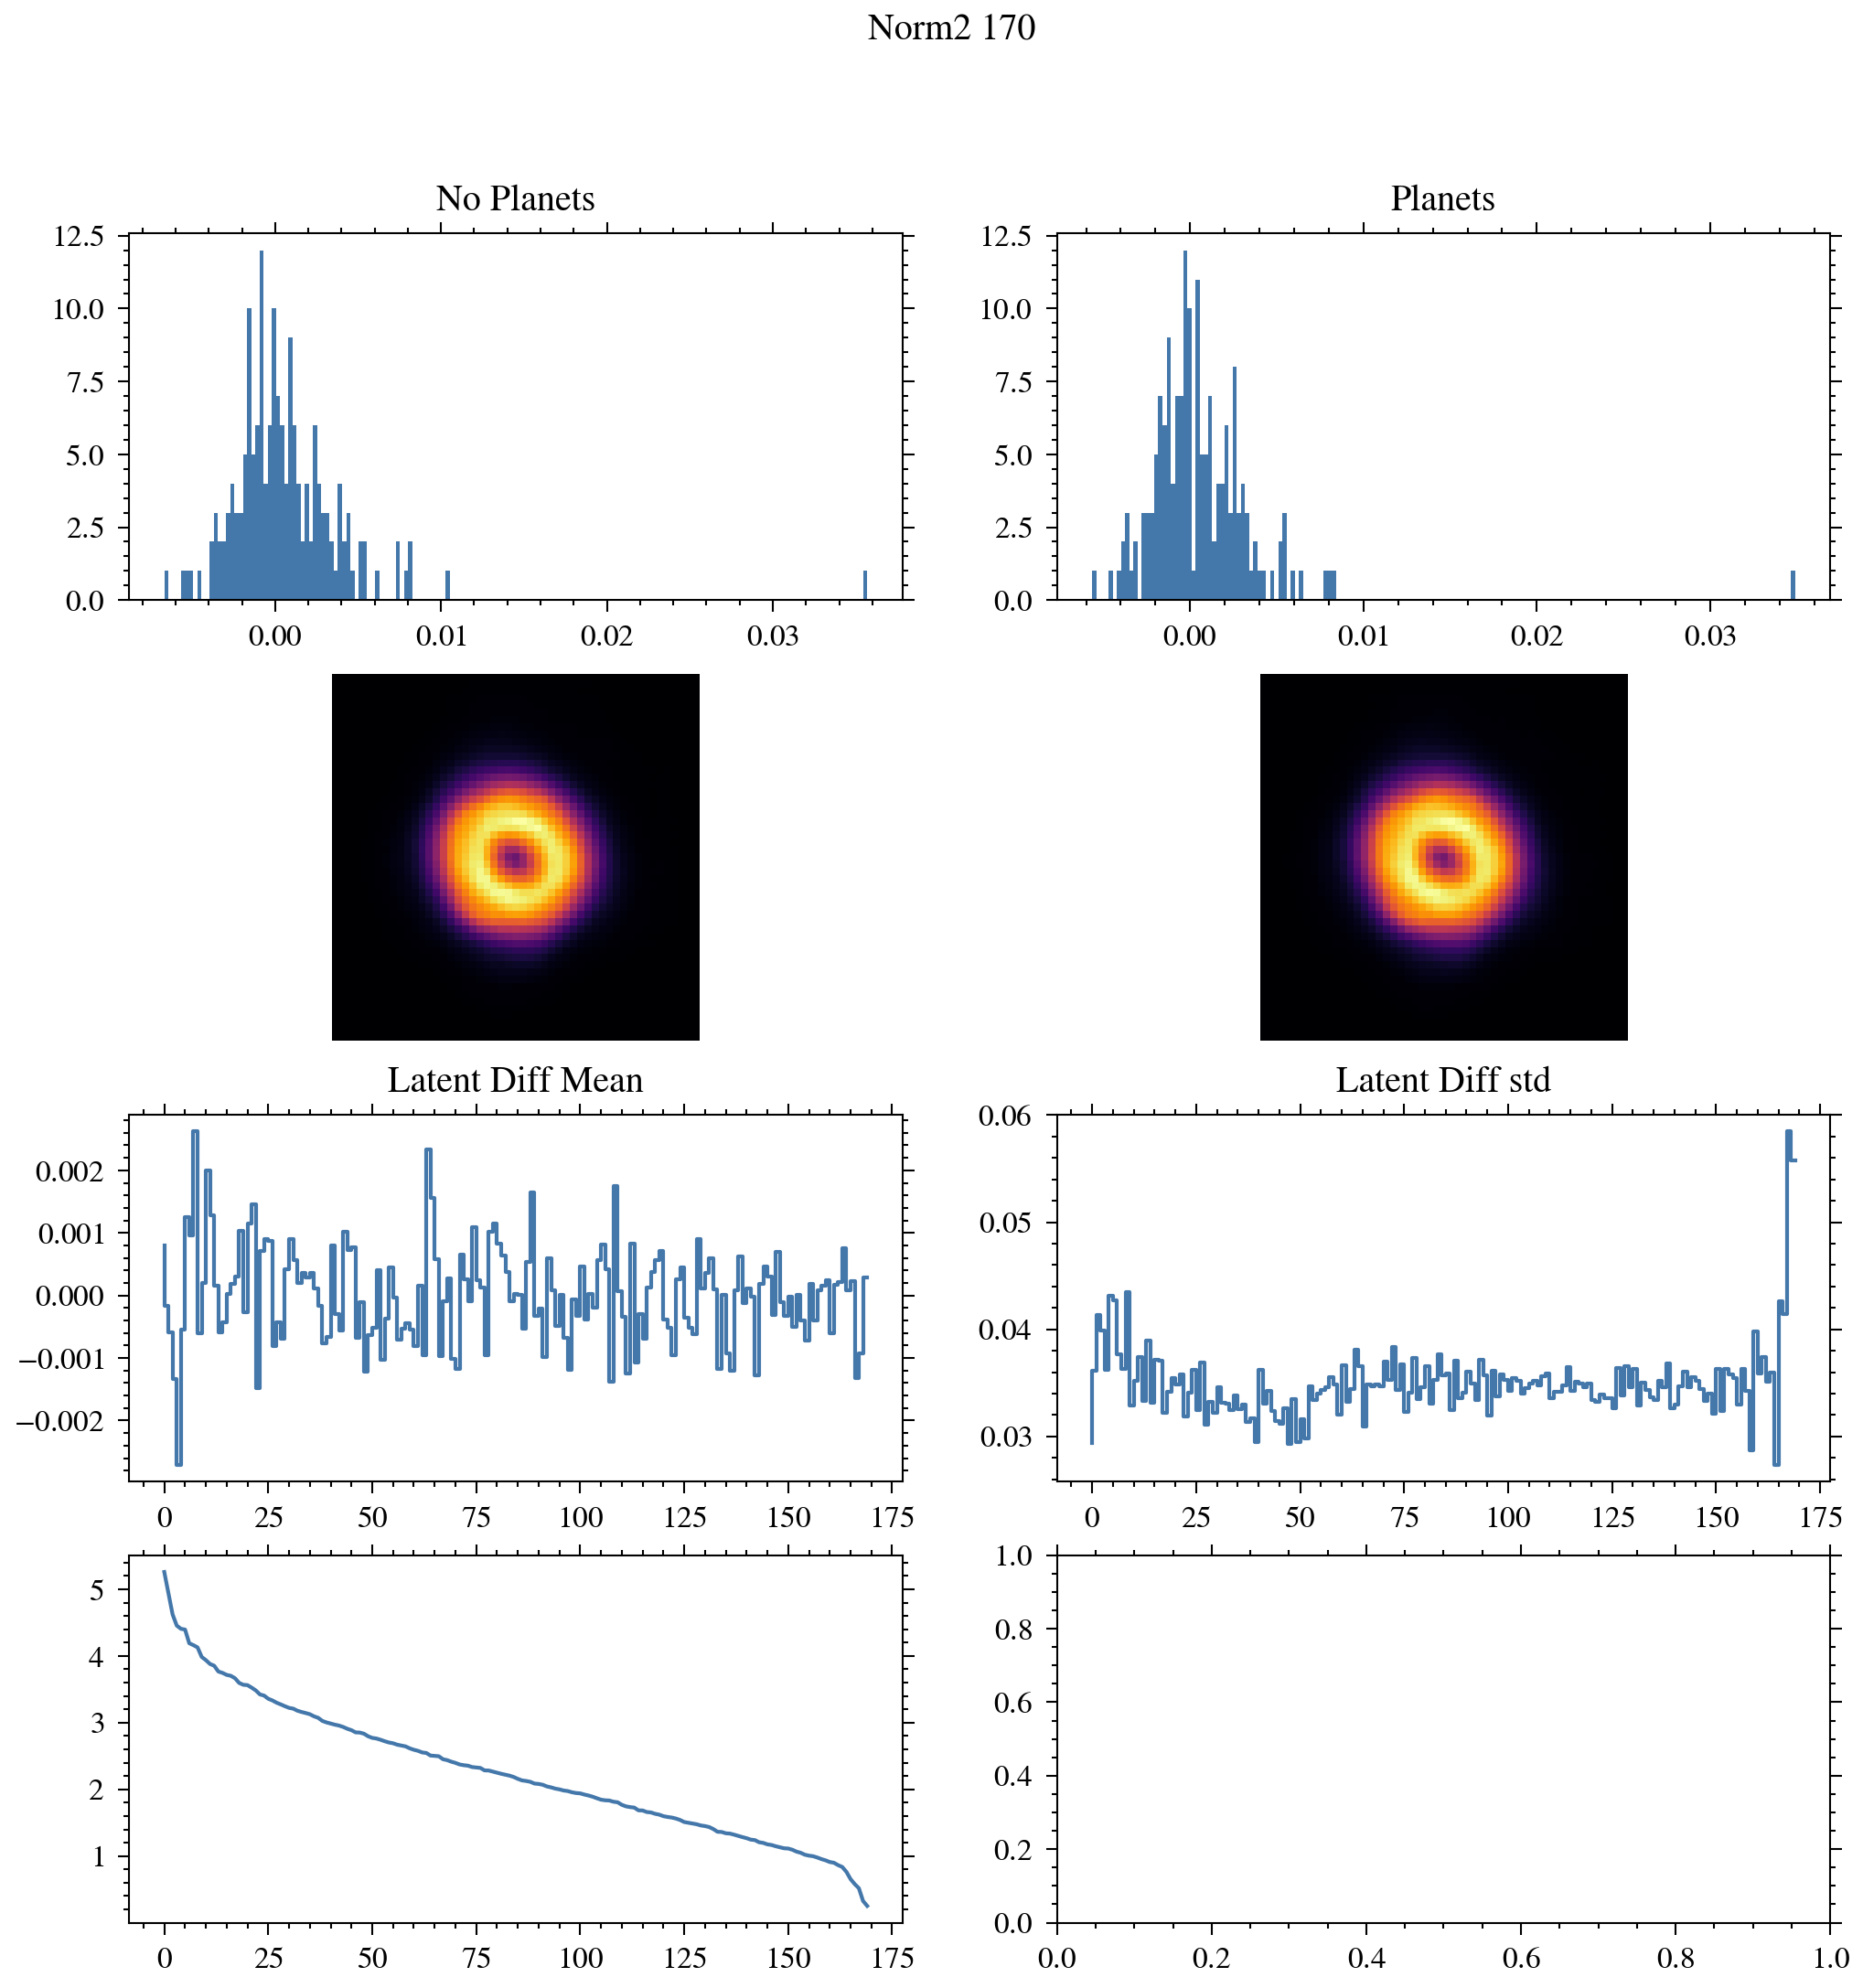

In [290]:
no_planets_norm2_latent_mean = np.mean(no_planets_norm2_latent, axis=0)
planets_norm2_latent_mean = np.mean(planets_norm2_latent, axis=0)
fig, axes = plt.subplots(4,2, figsize=(8,8))
axes[0,0].hist(no_planets_norm2_latent_mean, bins=170)
axes[0,0].set_title('No Planets')
axes[0,1].hist( planets_norm2_latent_mean, bins=170)
axes[0,1].set_title('Planets')
axes[1,0].imshow(norm2_decoder(no_planets_norm2_latent_mean)[0])
axes[1,0].set_axis_off()
axes[1,1].imshow(norm2_decoder(planets_norm2_latent_mean)[0])
axes[1,1].set_axis_off()
norm2_latent_diff = no_planets_norm2_latent-planets_norm2_latent_mean
norm2_latent_diff_mean = np.mean(norm2_latent_diff, axis=0)
axes[2,0].step(np.arange(170), norm2_latent_diff_mean)
axes[2,0].set_title('Latent Diff Mean')
norm2_latent_diff_std = np.std(norm2_latent_diff, axis=0)
axes[2,1].step(np.arange(170), norm2_latent_diff_std)
axes[2,1].set_title('Latent Diff std')
latent_diff_mean0 = norm2_latent_diff - norm2_latent_diff_mean
u,s,v = np.linalg.svd(latent_diff_mean0)
axes[3,0].plot(np.arange(170), s)
fig.suptitle('Norm2 170')

Text(0.5, 1.0, 'Base: Mean Difference No Planet - planet')

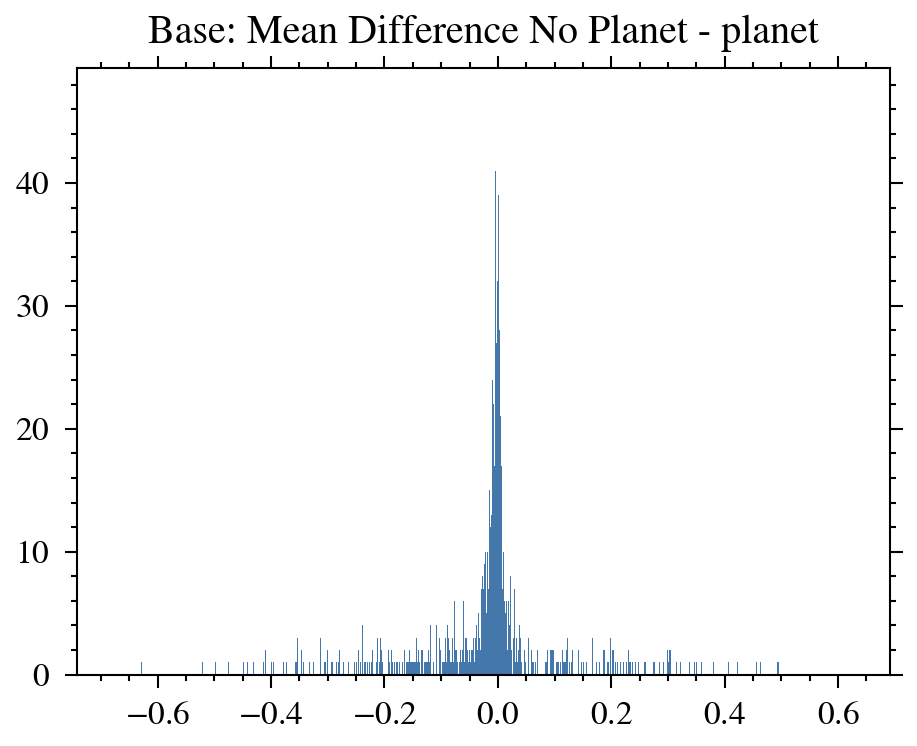

In [ ]:

plt.hist(base_latent_diff_mean, bins=2048)
plt.title('Base: Mean Difference No Planet - planet')

Text(0.5, 0.98, 'Normalized 2048')

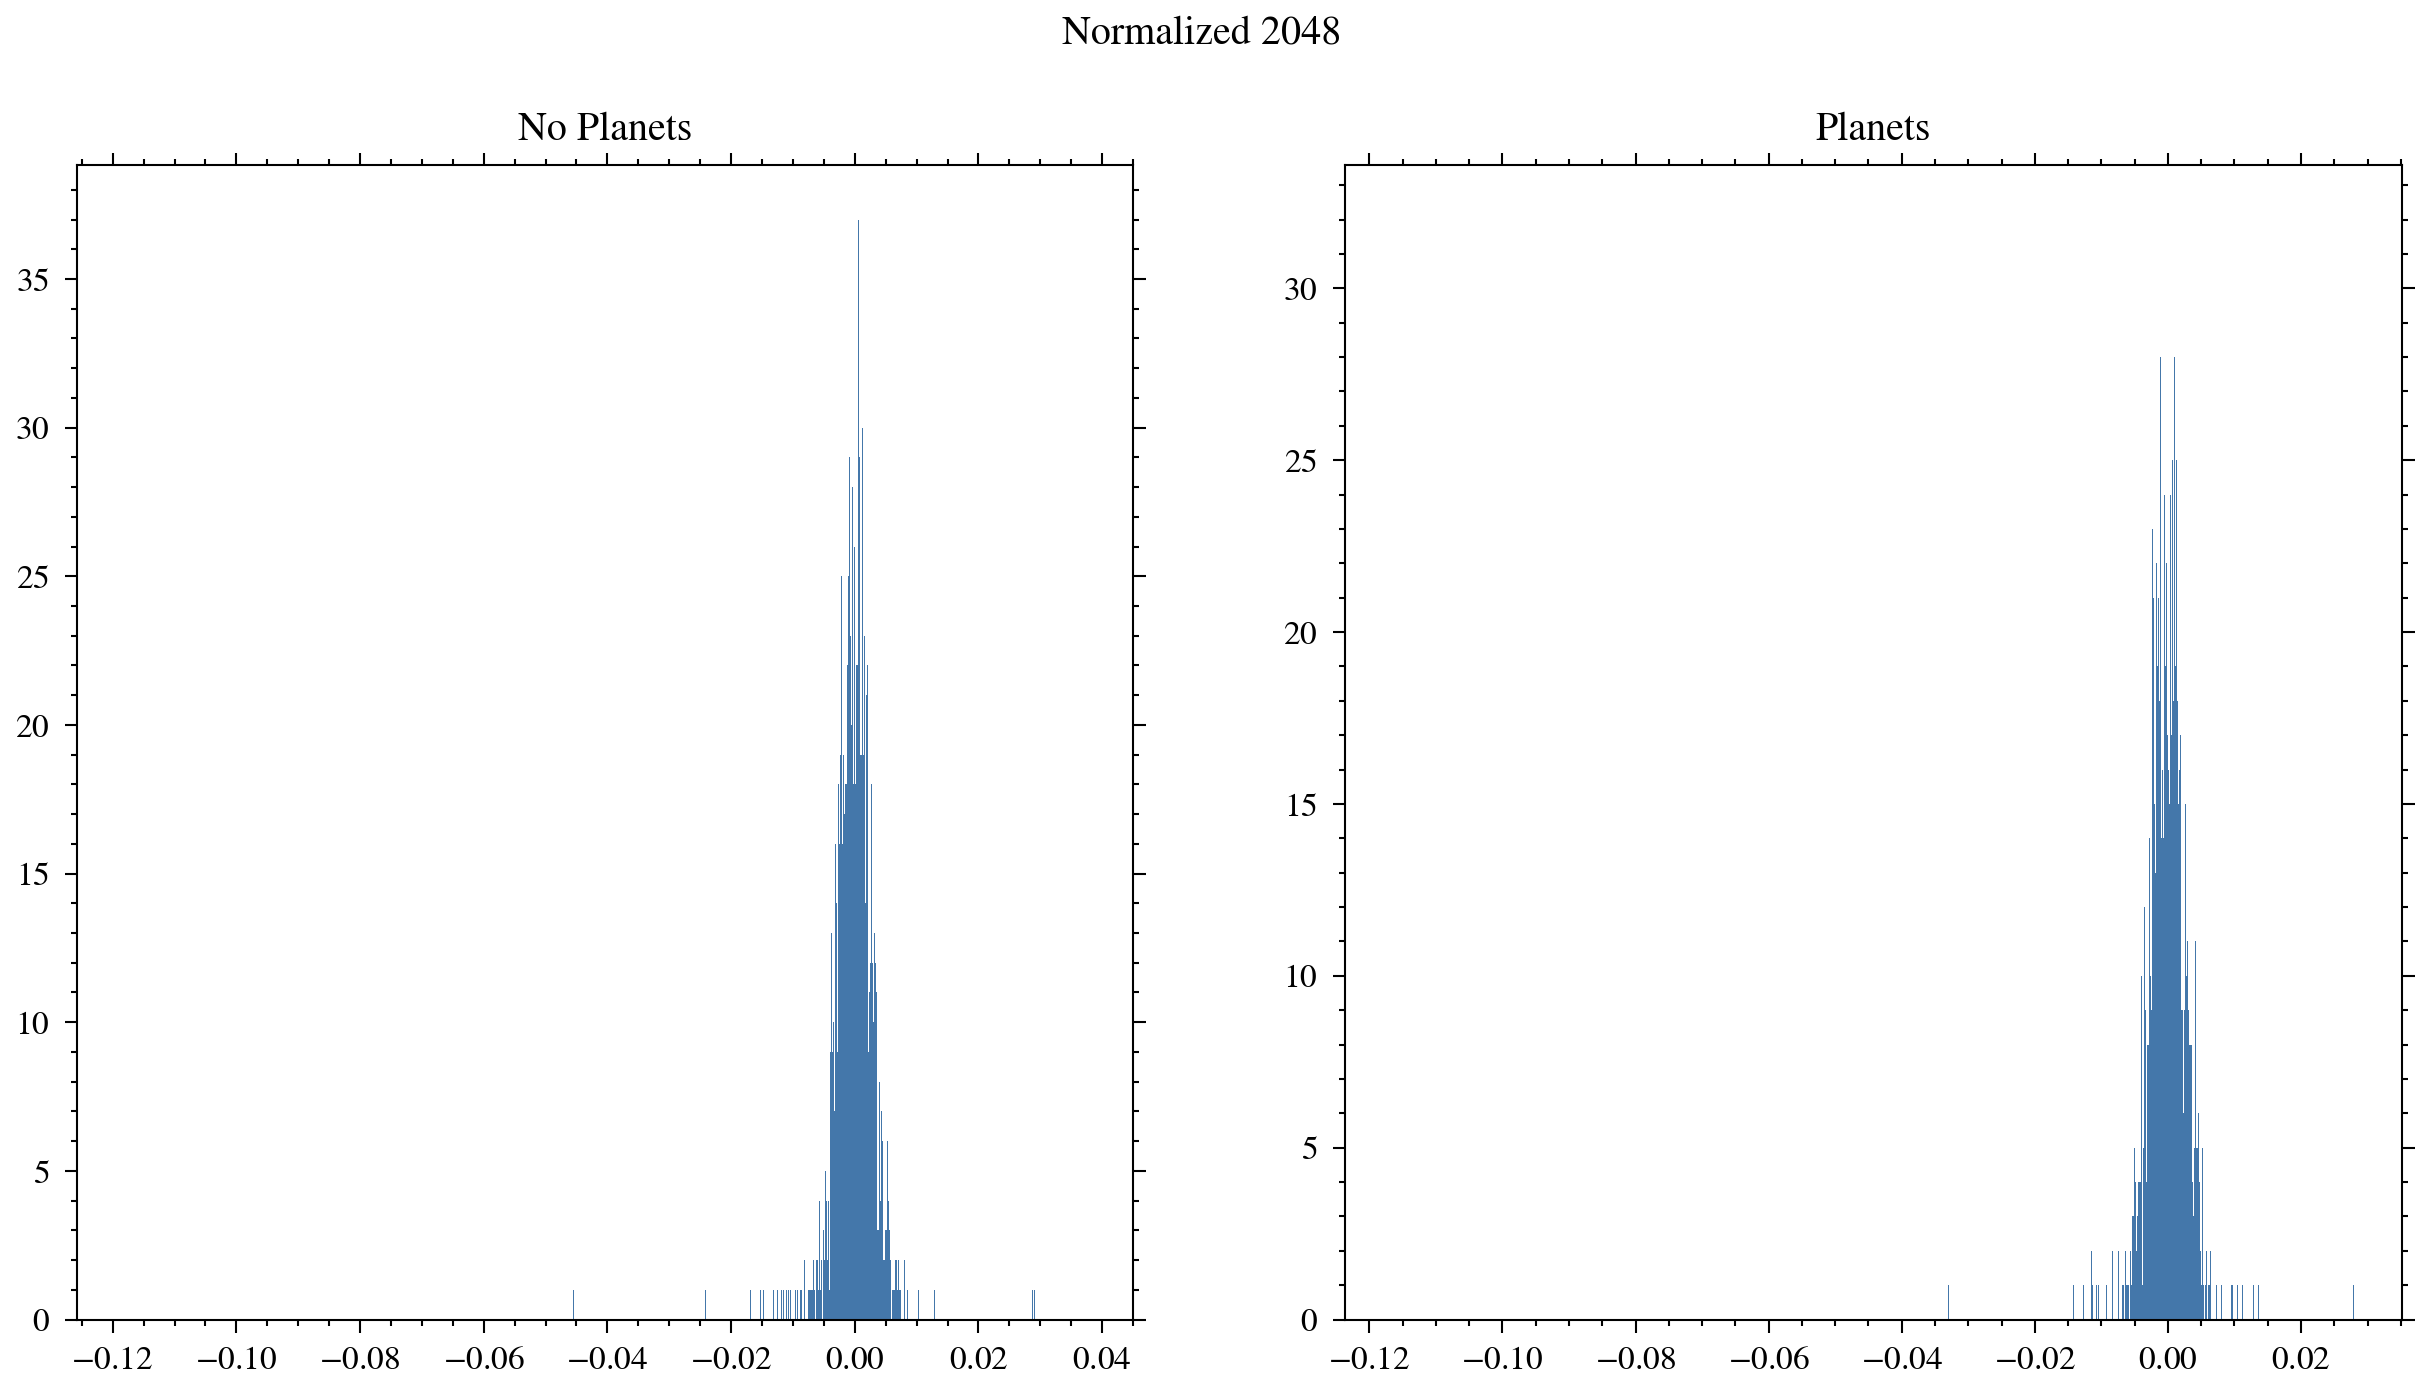

In [231]:
no_planets_norm0_latent_mean = np.mean(no_planets_norm0_latent, axis=0)
planets_norm0_latent_mean = np.mean(planets_norm0_latent, axis=0)
fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].hist(no_planets_norm0_latent_mean, bins=2048)
axes[0].set_title('No Planets')
axes[1].hist(planets_norm0_latent_mean, bins=2048)
axes[1].set_title('Planets')
fig.suptitle('Normalized 2048')

Text(0.5, 1.0, 'Norm0: Mean Difference No Planet - planet')

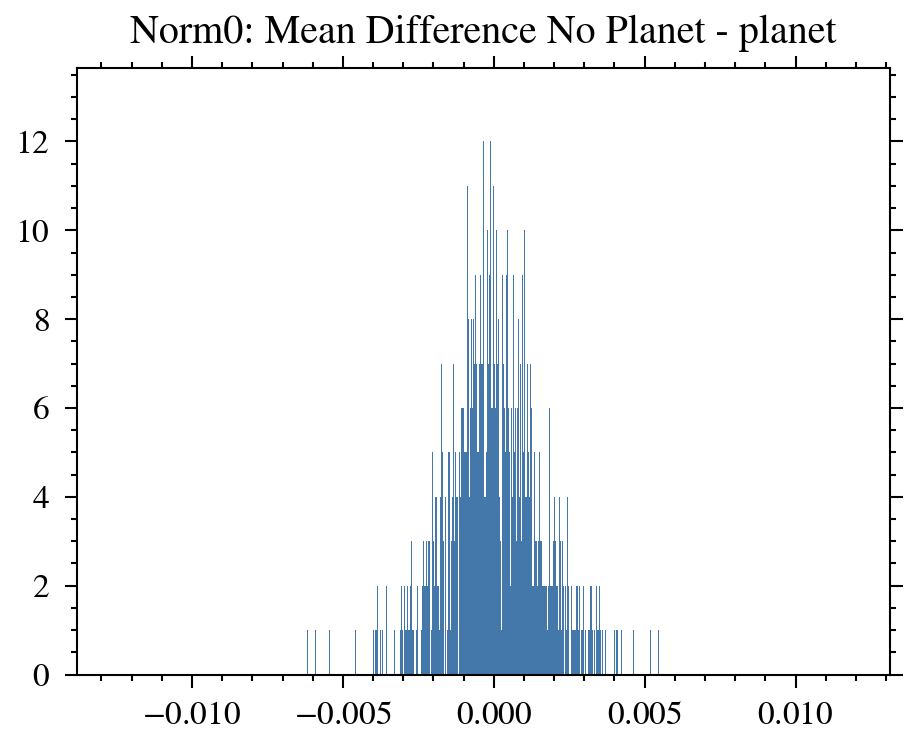

In [232]:
norm0_latent_diff = no_planets_norm0_latent-planets_norm0_latent_mean
norm0_latent_diff_mean = np.mean(norm0_latent_diff, axis=0)
plt.hist(norm0_latent_diff_mean, bins=2048)
plt.title('Norm0: Mean Difference No Planet - planet')

In [233]:
norm0_latent_diff_mean0.shape

(1000, 2048)

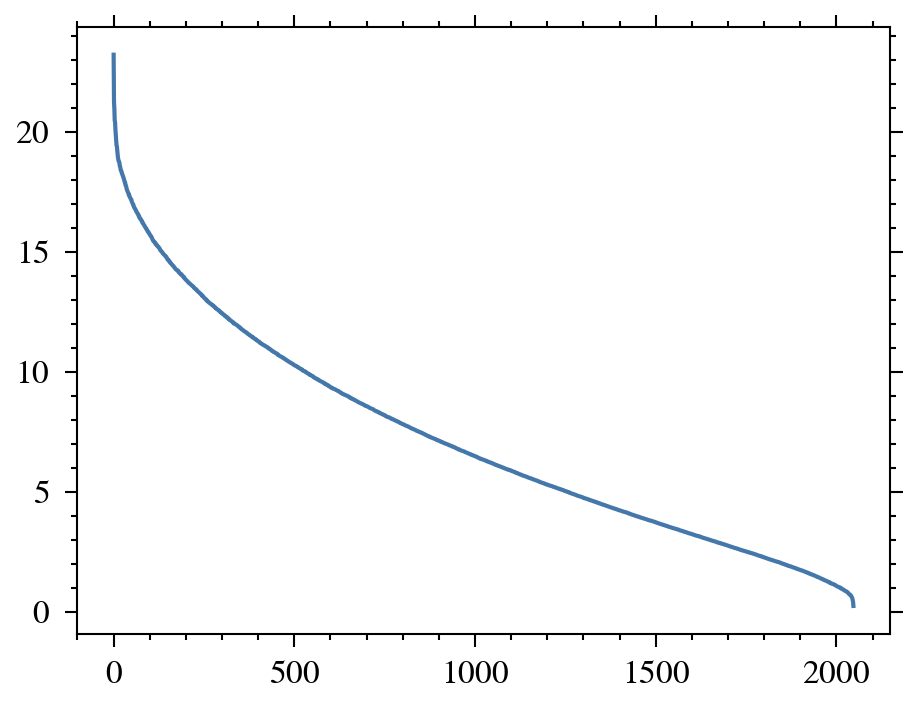

In [234]:
norm0_latent_diff_mean0 = norm0_latent_diff - norm0_latent_diff_mean
u,s,v = np.linalg.svd(norm0_latent_diff_mean0.T)
s.shape
plt.plot(np.arange(2048), s)


Text(0.5, 0.98, '170 Normed to 2048')

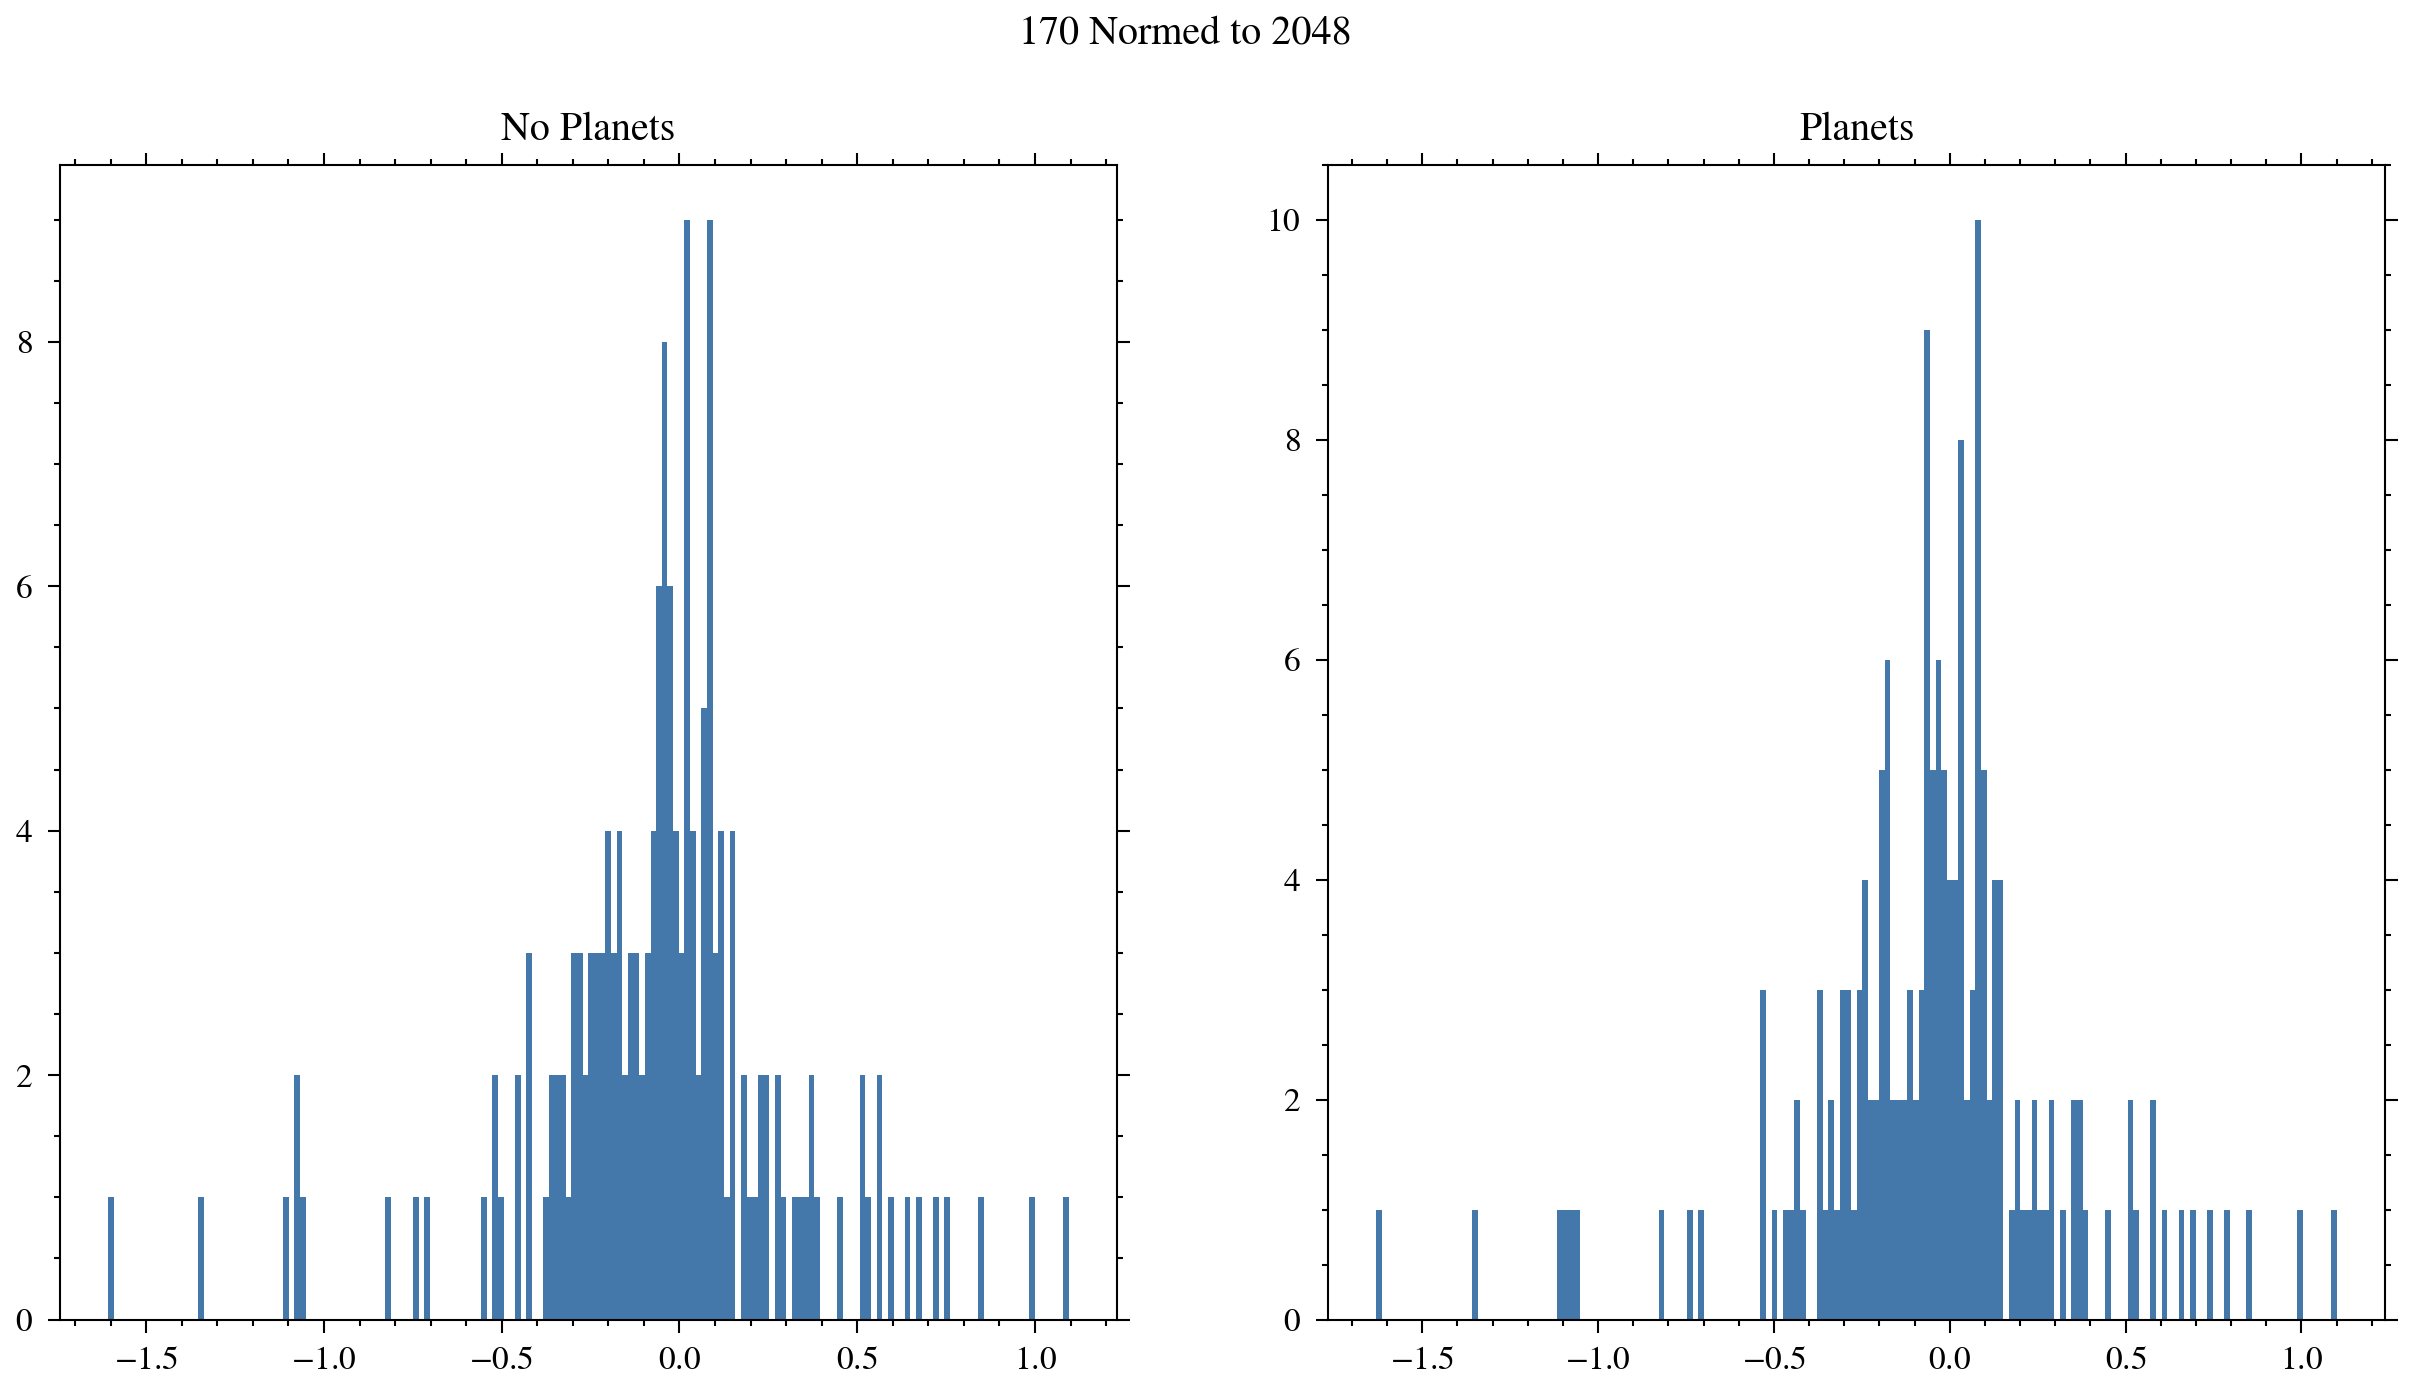

In [235]:
no_planets_norm1_latent_mean = np.mean(no_planets_norm1_latent, axis=0)
planets_norm1_latent_mean = np.mean(planets_norm1_latent, axis=0)
fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].hist(no_planets_norm1_latent_mean, bins=170)
axes[0].set_title('No Planets')
axes[1].hist(planets_norm1_latent_mean, bins=170)
axes[1].set_title('Planets')
fig.suptitle("170 Normed to 2048")

Text(0.5, 1.0, 'Norm1: Mean Difference No Planet - planet')

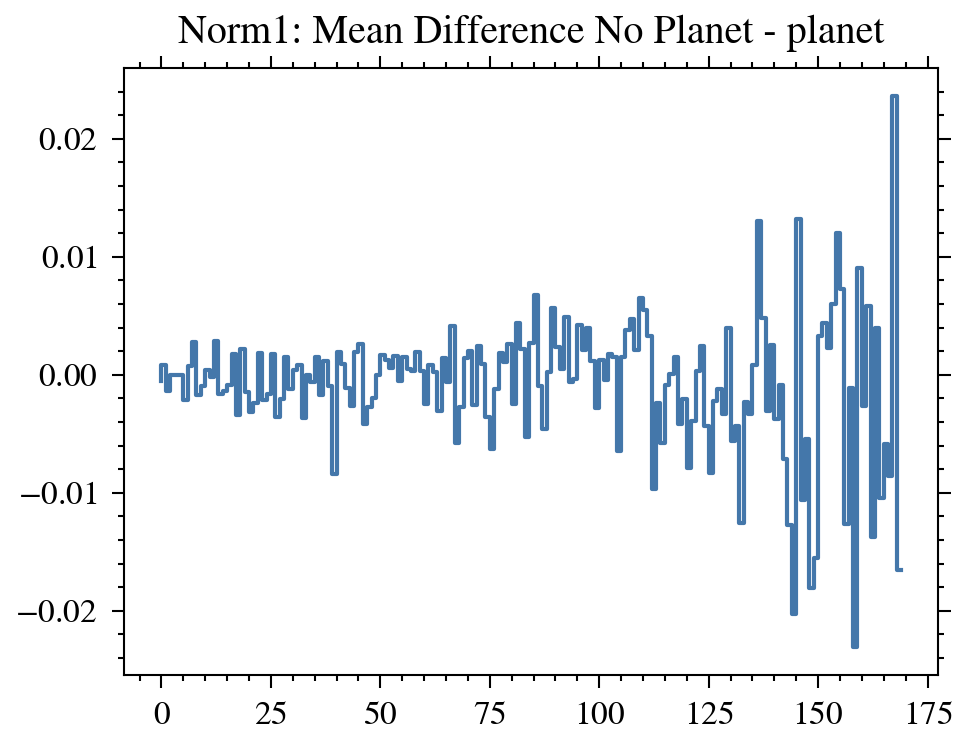

In [236]:
norm1_latent_diff = no_planets_norm1_latent-planets_norm1_latent_mean
norm1_latent_diff_mean = np.mean(norm1_latent_diff, axis=0)
plt.step(np.arange(170),norm1_latent_diff_mean)
plt.title('Norm1: Mean Difference No Planet - planet')

(170,)


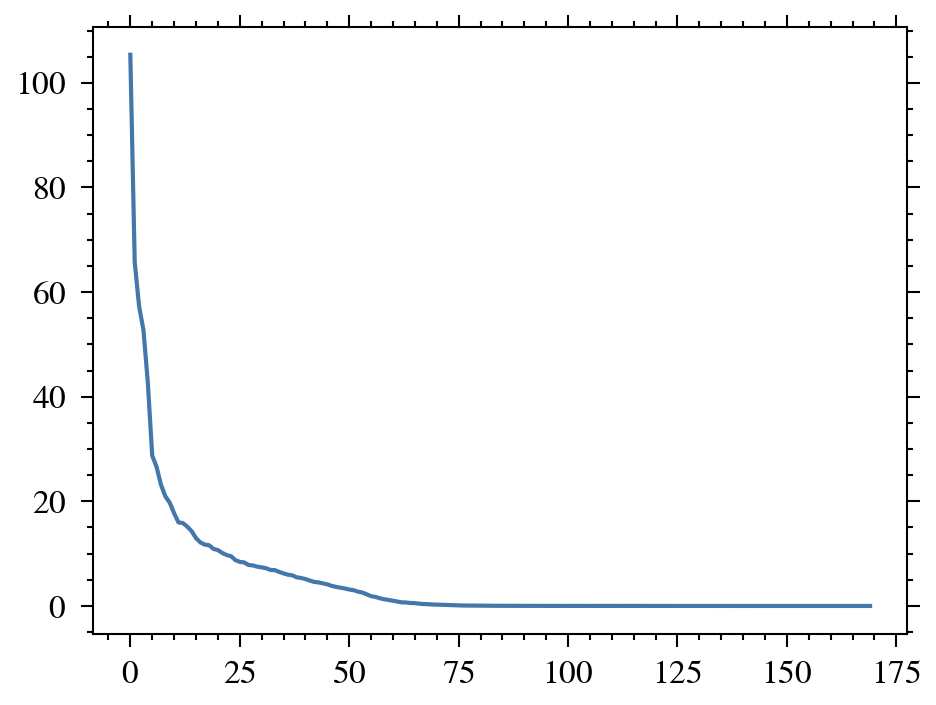

In [243]:
norm1_latent_diff_mean0 = norm1_latent_diff - norm1_latent_diff_mean
u,s,v = np.linalg.svd(norm1_latent_diff_mean0.T)
print(s.shape)
plt.plot(np.arange(170), s)

Text(0.5, 0.98, '170 Norm to 170')

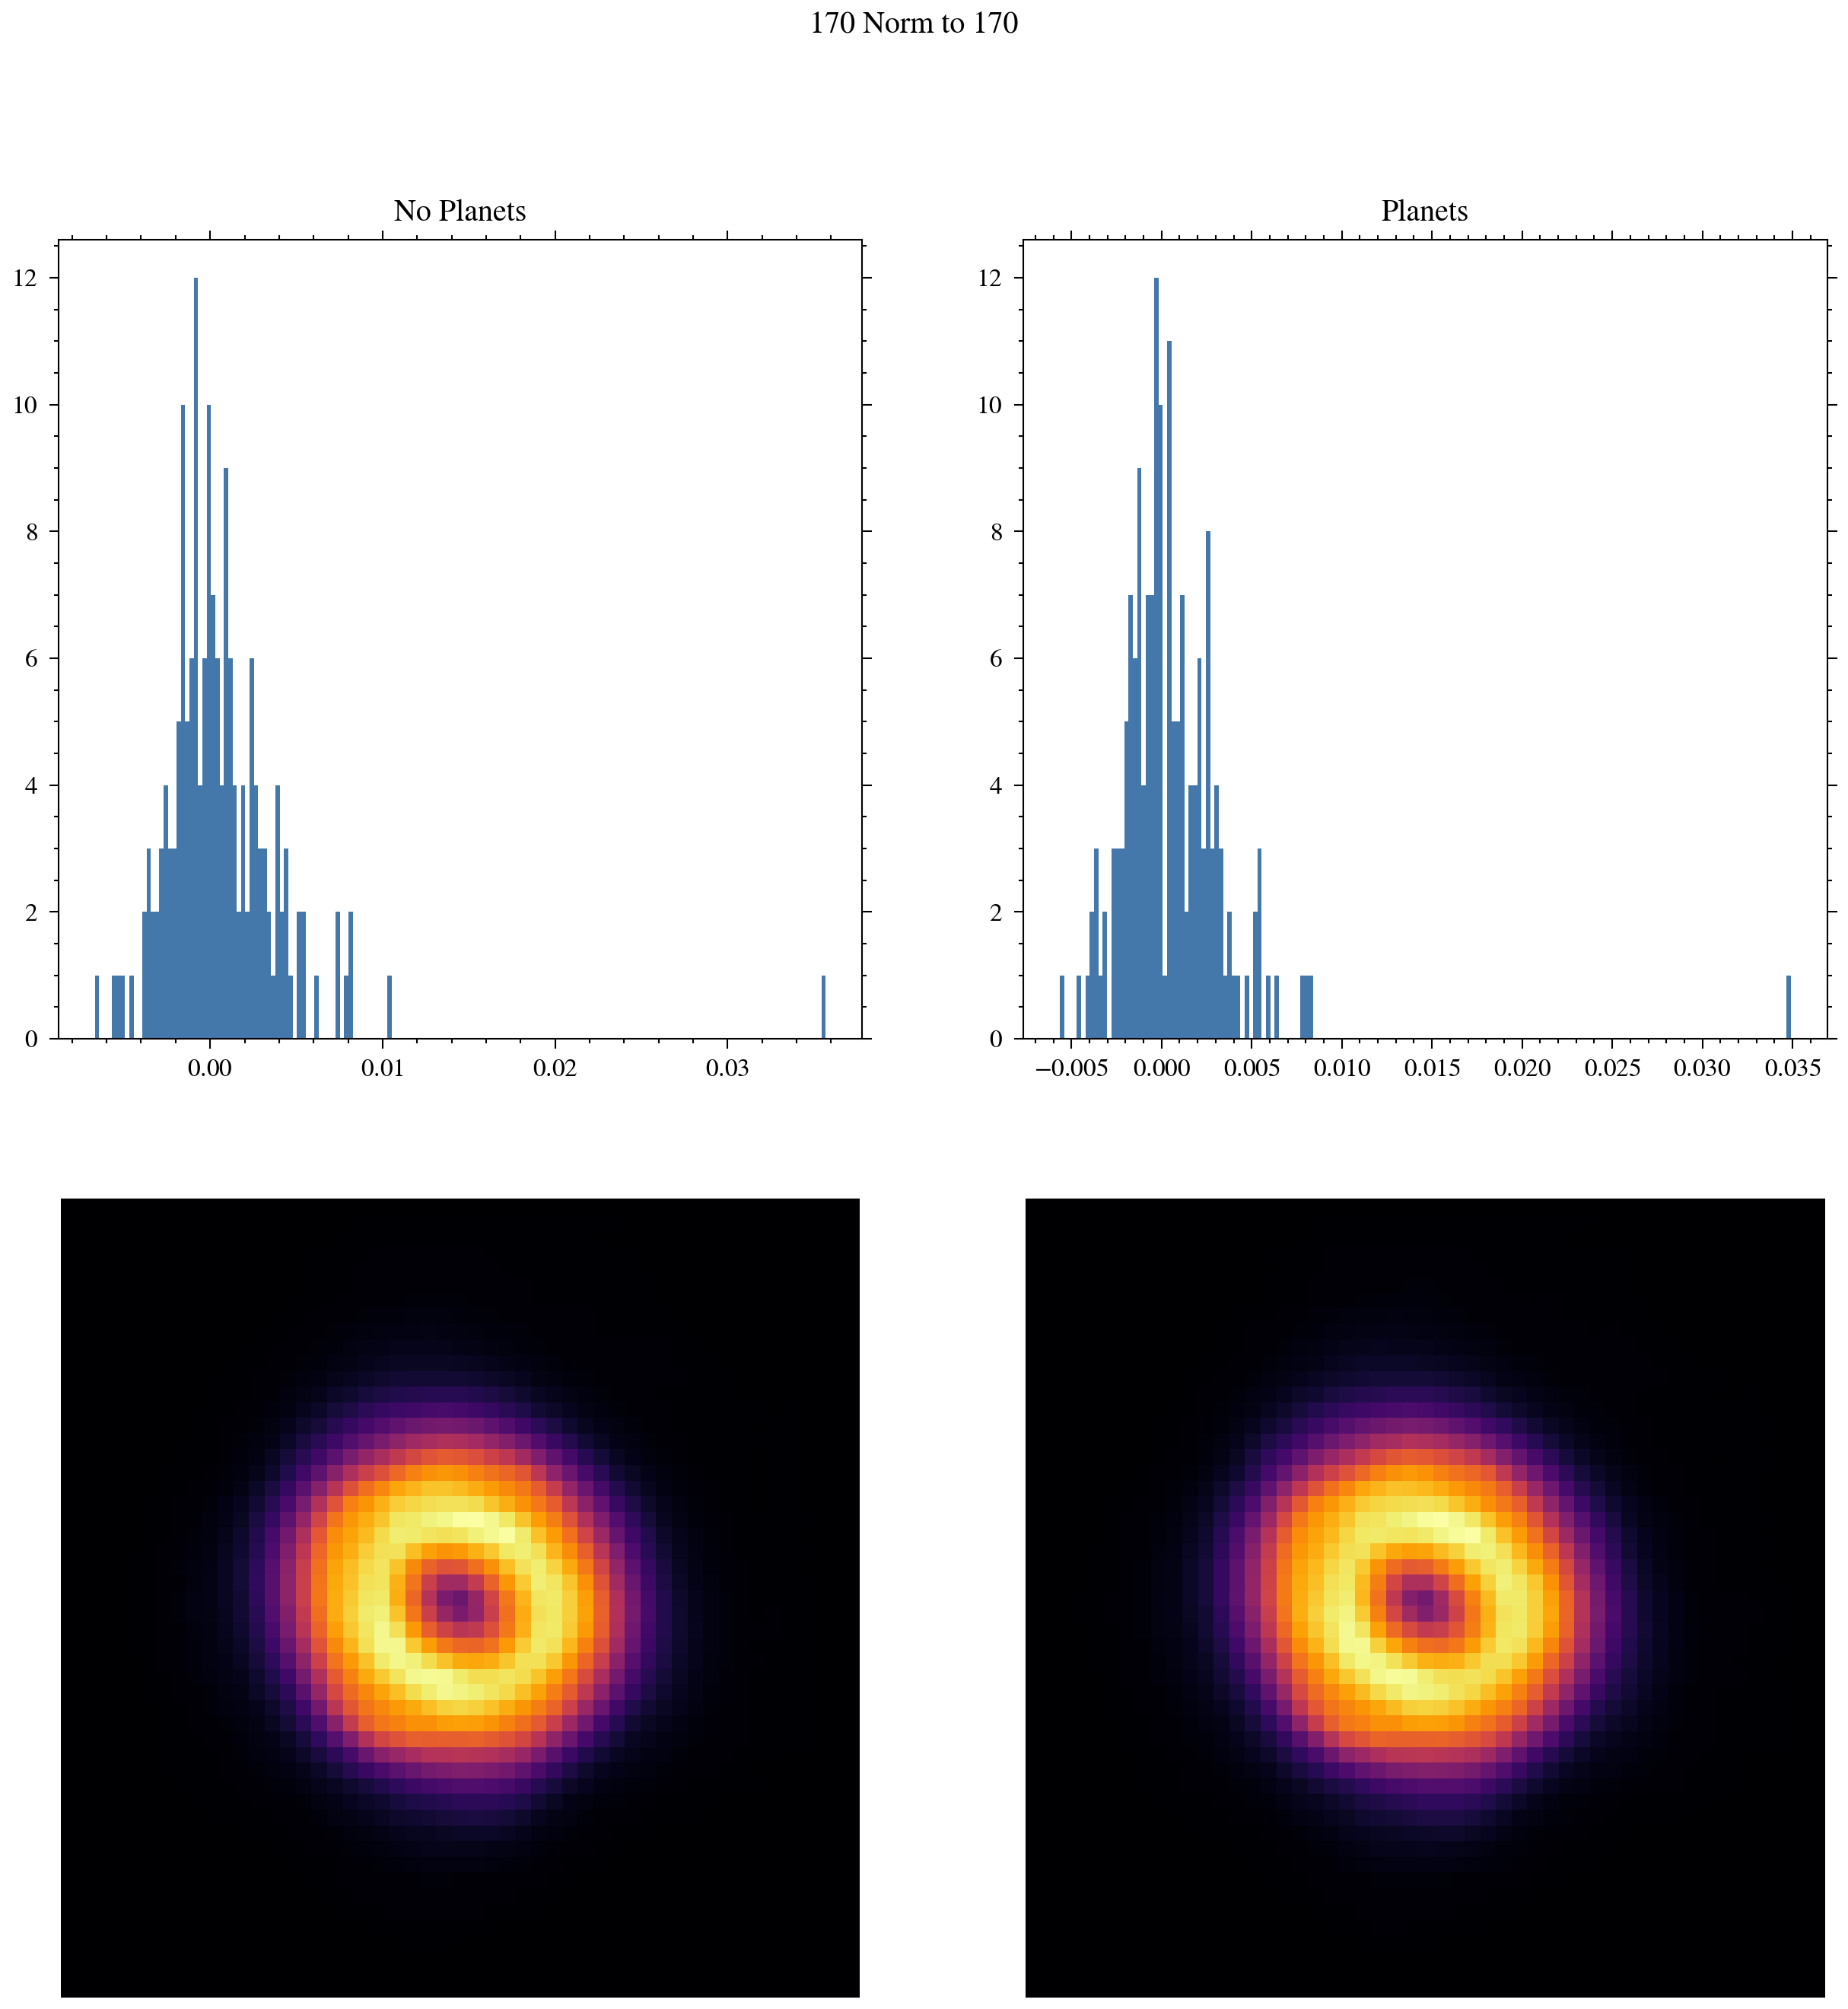

In [239]:
no_planets_norm2_latent_mean = np.mean(no_planets_norm2_latent, axis=0)
planets_norm2_latent_mean = np.mean(planets_norm2_latent, axis=0)
fig, axes = plt.subplots(2,2, figsize=(10,10))
axes[0,0].hist(no_planets_norm2_latent_mean, bins=170)
axes[0,0].set_title('No Planets')
axes[1,0].imshow(norm2_decoder(no_planets_norm2_latent_mean)[0],cmap='inferno')
axes[1,0].set_axis_off()
axes[0,1].hist(planets_norm2_latent_mean, bins=170)
axes[0,1].set_title('Planets')
axes[1,1].imshow(norm2_decoder(planets_norm2_latent_mean)[0],cmap='inferno')
axes[1,1].set_axis_off()
fig.suptitle("170 Norm to 170")

Text(0.5, 1.0, 'Norm2: Mean Difference No Planet - planet')

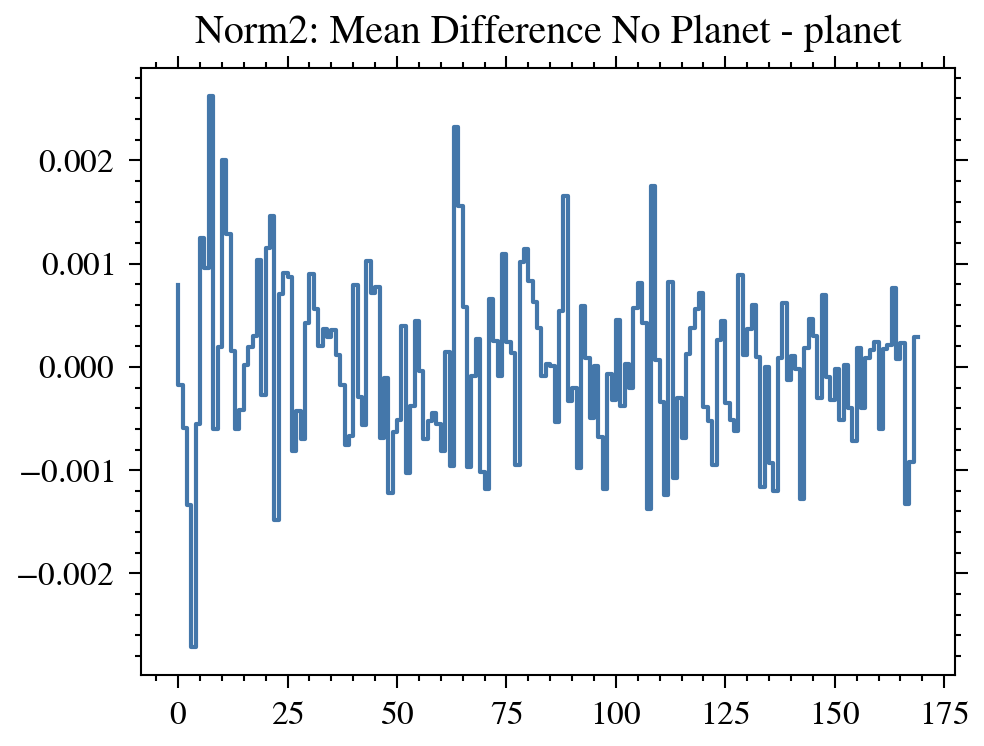

In [ ]:
norm2_latent_diff = no_planets_norm2_latent-planets_norm2_latent_mean
norm2_latent_diff_mean = np.mean(norm2_latent_diff, axis=0)
norm2_latent_diff_std = np.std(norm2_latent_diff, axis=0)
plt.step(np.arange(170),norm2_latent_diff_mean)
plt.title('Norm2: Mean Difference No Planet - planet')

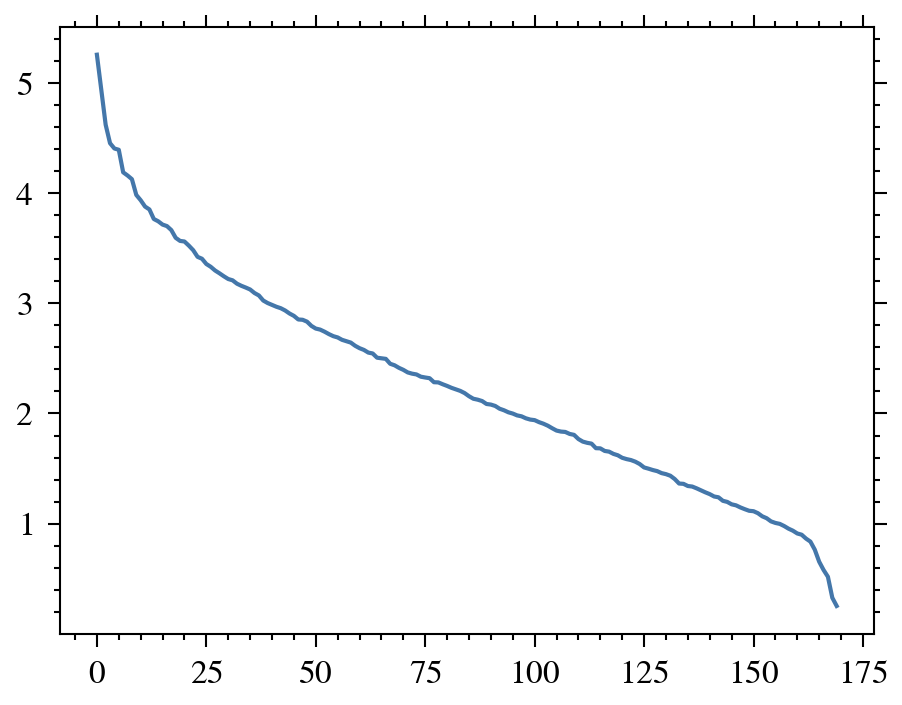

In [241]:
norm2_latent_diff_mean0 = norm2_latent_diff - norm2_latent_diff_mean
u,s,v = np.linalg.svd(norm2_latent_diff_mean0.T)
plt.plot(np.arange(170), s)

In [242]:
s.shape

(170,)

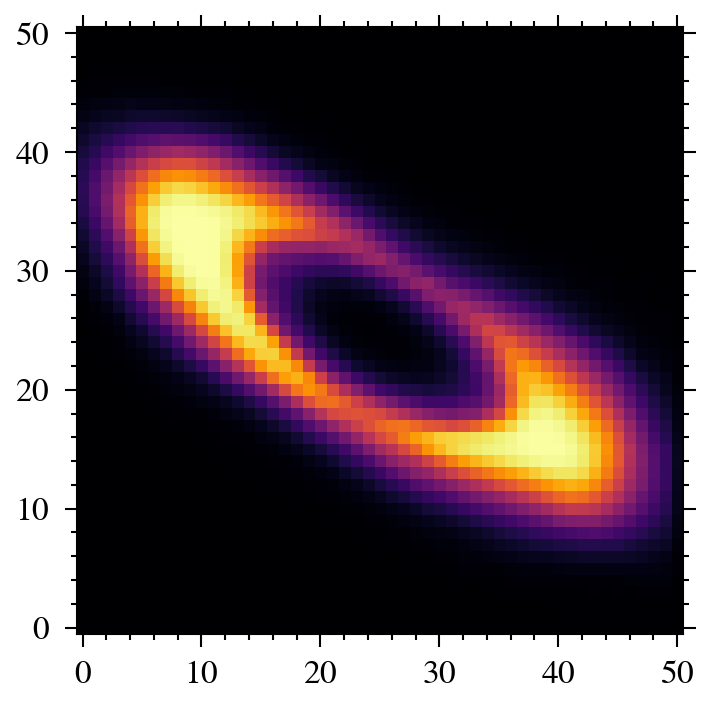

In [353]:
noplanet=no_planets_norm2_latent[5000]
planet=planets_norm2_latent[5000]
diff=norm2_latent_diff[300]
plt.imshow(norm2_decoder(diff+noplanet)[0])

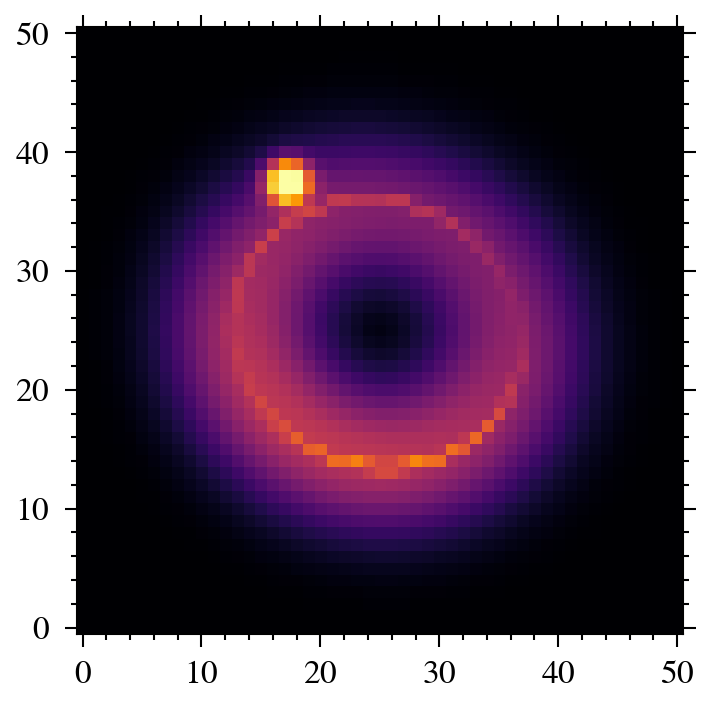

In [352]:
plt.imshow(planets[300][0])